# Measured gamma data analysis

This notebook processes the gamma measurements recorded with the GCA-07W-DL
and its external LND 712 Geiger--Mueller wand around the moderated Am--Be
source. It has one purpose: create a clean, background-corrected and
geometry-ready measured-gamma dataset for Notebook 5.

The front panel was set to the metric `mSv/hr` display scale and the one-second
`CPS` counting mode. The data logger nevertheless stores the primary measured
quantity as

$$
R_\gamma \quad [\mathrm{CPS}],
$$

in files with the columns `elapsed_s, cps`. The CPS column is therefore not
divided by time a second time. After local-background subtraction, the project
conversion $0.60\ \mu\mathrm{Sv/h/CPS}$ is used to report a GCA-indicated,
Cs-137-equivalent gamma dose rate. That derived indication is not photon flux,
an energy-response-corrected Am--Be photon dose, or ICRP-116 AP effective dose.

The required input folders are:

```text
gamma_logs_baggrund
gamma_logs_P1
gamma_logs_P2
gamma_logs_P3
gamma_logs_P4
gamma_logs_P5
```

## Workflow

1. Read and validate every two-column gamma log.
2. Consolidate repeats and subtract the nearest-height outside-door background.
3. Propagate counting, repeatability and background SEM terms.
4. Insert P1--P5 points into the shared LND 712 active-volume geometry.
5. Export the canonical tables immediately.
6. Produce linear, semi-log, position-panel, attenuation, XY and SEM figures.


In [1]:
# 1) Setup, paths and physical conventions

from pathlib import Path
from itertools import combinations
import importlib
import json
import re

import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)


def find_project_root(start):
    """Find the nearest folder containing the measured-gamma folders."""
    start = Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "gamma_logs_P1").is_dir():
            return candidate
    return start


BASE_DIR = find_project_root(Path.cwd())
POSITION_SEQUENCE = ["P1", "P2", "P3", "P4", "P5"]
POSITION_ORDER = {
    position: index for index, position in enumerate(POSITION_SEQUENCE)
}
LOG_FOLDERS = {
    "background": BASE_DIR / "gamma_logs_baggrund",
    **{
        position: BASE_DIR / f"gamma_logs_{position}"
        for position in POSITION_SEQUENCE
    },
}

OUTPUT_DIR = BASE_DIR / "N4_5_measured_gamma_outputs"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
METADATA_DIR = OUTPUT_DIR / "metadata"
for folder in (TABLE_DIR, FIGURE_DIR, METADATA_DIR):
    folder.mkdir(parents=True, exist_ok=True)

POSITION_COLORS = {
    "P1": "tab:blue",
    "P2": "tab:orange",
    "P3": "tab:green",
    "P4": "tab:red",
    "P5": "tab:purple",
}
DIRECTION_COLOURS = POSITION_COLORS


def lighten_color(color, amount):
    """Blend a Matplotlib colour toward white by ``amount``."""
    base_rgb = np.asarray(to_rgb(color), dtype=float)
    return tuple((1.0 - amount) * base_rgb + amount * np.ones(3))


def make_position_height_colors(dataframe):
    """Use one base colour per P direction and a shade per real height."""
    colour_map = {}
    for position in POSITION_SEQUENCE:
        heights = np.sort(
            dataframe.loc[dataframe["position"] == position, "height_cm"]
            .dropna().astype(float).unique()
        )
        amounts = (
            np.array([0.0])
            if len(heights) <= 1
            else np.linspace(0.0, 0.48, len(heights))
        )
        for height_cm, amount in zip(heights, amounts):
            colour_map[(position, float(height_cm))] = lighten_color(
                POSITION_COLORS[position], amount
            )
    return colour_map


# Instrument settings used during the measurements.
GAMMA_INSTRUMENT_MODEL = "GCA-07W-DL"
GAMMA_DETECTOR_MODEL = "LND 712 Geiger-Mueller tube in external wand"
GCA_DISPLAY_DOSE_SCALE = "mSv/hr"
GCA_COUNT_MODE = "CPS"
GCA_COUNT_WINDOW_S = 1.0
GCA_LOGGED_QUANTITY = "counts per second"

# The manual's display example gives 46 CPS = 2.760 mR/h.
# Hence 0.060 mR/h/CPS × 10 uSv/mR = 0.60 uSv/h/CPS.
GAMMA_CALIBRATION_USV_H_PER_CPS = 0.60
GAMMA_CALIBRATION_REFERENCE_ENERGY_MEV = 0.662
GAMMA_CALIBRATION_REFERENCE = (
    "GCA-07W-DL manual: 46 CPS = 2.760 mR/h; Cs-137 response"
)

LND712_EFFECTIVE_DIAMETER_CM = 0.91
LND712_EFFECTIVE_LENGTH_CM = 3.81
LND712_ACTIVE_CENTRE_OFFSET_CM = LND712_EFFECTIVE_LENGTH_CM / 2.0
LND712_ACTIVE_VOLUME_CM3 = (
    np.pi * (LND712_EFFECTIVE_DIAMETER_CM / 2.0) ** 2
    * LND712_EFFECTIVE_LENGTH_CM
)

# The mica window faces the cabinet and the tube axis follows the scan line.
GAMMA_AXIS_ALIGNMENT_DEG = 0.0
GAMMA_AXIS_ALIGNMENT_UNCERTAINTY_DEG = 1.0
MEASUREMENT_POSITION_UNCERTAINTY_CM = 1.0
MEASUREMENT_HEIGHT_UNCERTAINTY_CM = 1.0
ORIENTATION_TRANSVERSE_LIMIT_CM = (
    LND712_ACTIVE_CENTRE_OFFSET_CM
    * np.sin(np.deg2rad(GAMMA_AXIS_ALIGNMENT_UNCERTAINTY_DEG))
)

GAMMA_MANUFACTURER_ACCURACY_LIMIT_PERCENT = 5.0
GAMMA_CONSERVATIVE_COUNTABLE_RANGE_MAX_CPS = 5000.0
GAMMA_FEATURE_LIST_COUNTABLE_RANGE_MAX_CPS = 10000.0
REQUIRED_BACKGROUND_HEIGHTS_CM = {50.0, 85.0}
LOCAL_BACKGROUND_PATTERN = r"p6.*udenfor.*d(?:o|ø|oe)r"
AP_EFFECTIVE_DOSE_EQUIVALENCE_ASSUMED = False

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 170)
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

print(f"Project folder: {BASE_DIR}")
print(f"Output folder:  {OUTPUT_DIR}")
print(f"Instrument setting: {GCA_DISPLAY_DOSE_SCALE}, {GCA_COUNT_MODE}")
print("Logged primary quantity: elapsed_s and CPS")


Project folder: /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn
Output folder:  /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N4_5_measured_gamma_outputs
Instrument setting: mSv/hr, CPS
Logged primary quantity: elapsed_s and CPS


# 2) Filename and TXT decoding

Scan filenames use forms such as `G_P1_x_6_y_50_10_min.txt` and
`G_P1_x_30_y_38_10min.txt`. Here `x` is the measured gap from the cabinet
surface to the detector's mica-window plane, and `y` is the detector height
above the cabinet bottom. Optional replicate suffixes do not create new
physical points.

Each file must begin with a comment header containing `elapsed_s` and `cps`,
followed by two numerical columns. In the selected CPS mode, each row is a
one-second count-rate observation. For $n$ valid rows,

$$
\mathrm{SEM}_{\mathrm{sample}}=\frac{s_R}{\sqrt n},
\qquad
u_{\mathrm{Poisson}}(R)=\frac{\sqrt N}{T}.
$$

The larger finite estimate is retained at file level. The metric `mSv/hr`
switch controls the simultaneous front-panel indication; it does not turn the
logged CPS column into a dose-rate column.


In [2]:
# Filename parsing and robust two-column TXT reader

def normalized_stem(path):
    text = Path(path).stem.strip().casefold()
    text = text.replace("–", "-").replace("—", "-").replace("−", "-")
    text = re.sub(r"[\s-]+", "_", text)
    return re.sub(r"_+", "_", text).strip("_")


def parse_number(token):
    return float(str(token).replace(",", ".").replace("p", "."))


def coordinate_token(value):
    value = float(value)
    return str(int(value)) if value.is_integer() else f"{value:g}".replace(".", "p")


def duration_from_stem(stem):
    matches = re.findall(r"(?:^|_)(\d+(?:[.,p]\d+)?)_?min(?:_|$)", stem)
    return parse_number(matches[-1]) if matches else np.nan


def parse_gamma_filename(path, folder_position):
    stem = normalized_stem(path)
    duration_min = duration_from_stem(stem)

    if folder_position == "background":
        height_match = re.search(
            r"(?:^|_)y_?(-?\d+(?:[.,p]\d+)?)(?:_|$)", stem
        )
        background_height_cm = (
            parse_number(height_match.group(1)) if height_match else np.nan
        )
        location = re.sub(r"(?:^|_)g(?=_|$)", "", stem)
        location = re.sub(r"(?:^|_)(?:background|baggrund)(?=_|$)", "", location)
        location = re.sub(
            r"(?:^|_)\d+(?:[.,p]\d+)?_?min(?:_\d+)?(?:_|$)", "", location
        )
        location = re.sub(r"_+", "_", location).strip("_") or "background"
        return {
            "measurement_kind": "background",
            "position": "background",
            "distance_cm": np.nan,
            "height_cm": background_height_cm,
            "background_height_cm": background_height_cm,
            "location_label": location,
            "physical_point_id": f"background_{location}",
            "duration_min": duration_min,
            "replicate_label": pd.NA,
        }

    match = re.search(
        r"(?:^|_)p(?P<position>[1-5])_x_?(?P<distance>-?\d+(?:[.,p]\d+)?)"
        r"_y_?(?P<height>-?\d+(?:[.,p]\d+)?)(?:_|$)",
        stem,
    )
    if not match:
        raise ValueError(f"Unrecognized gamma scan filename: {Path(path).name}")

    position = f"P{match.group('position')}"
    if position != folder_position:
        raise ValueError(
            f"Filename says {position}, but file is in {folder_position}."
        )
    distance_cm = parse_number(match.group("distance"))
    height_cm = parse_number(match.group("height"))
    if distance_cm < 0.0 or height_cm < 0.0:
        raise ValueError(f"Negative coordinate in {Path(path).name}.")

    duration_match = re.search(
        r"(?:^|_)(\d+(?:[.,p]\d+)?)_?min(?:_|$)", stem
    )
    suffix = stem[duration_match.end():].strip("_") if duration_match else ""
    replicate_match = re.search(r"(?:^|_)(\d+)(?:_|$)", suffix)
    point_id = (
        f"{position}_x{coordinate_token(distance_cm)}"
        f"_h{coordinate_token(height_cm)}"
    )
    return {
        "measurement_kind": "scan",
        "position": position,
        "distance_cm": distance_cm,
        "height_cm": height_cm,
        "background_height_cm": np.nan,
        "location_label": pd.NA,
        "physical_point_id": point_id,
        "duration_min": duration_min,
        "replicate_label": (
            replicate_match.group(1) if replicate_match else pd.NA
        ),
    }


def read_gamma_txt(path):
    path = Path(path)
    if not path.is_file():
        raise FileNotFoundError(path)

    first_comment = ""
    with path.open("r", encoding="utf-8-sig", errors="replace") as handle:
        for line in handle:
            stripped = line.strip()
            if stripped.startswith("#"):
                first_comment = stripped.casefold()
                break
            if stripped:
                break
    if "elapsed_s" not in first_comment or "cps" not in first_comment:
        raise ValueError(
            f"{path.name} must have a '# elapsed_s cps' header."
        )

    data = np.loadtxt(path, comments="#", ndmin=2)
    if data.size == 0 or data.shape[1] != 2:
        raise ValueError(
            f"{path.name} must contain exactly two numerical columns."
        )
    original_rows = int(data.shape[0])
    elapsed_s = np.asarray(data[:, 0], dtype=float)
    cps = np.asarray(data[:, 1], dtype=float)
    valid = np.isfinite(elapsed_s) & np.isfinite(cps) & (cps >= 0.0)
    elapsed_s = elapsed_s[valid]
    cps = cps[valid]
    valid_rows = int(valid.sum())
    if valid_rows == 0:
        raise ValueError(f"{path.name} contains no valid CPS rows.")

    order = np.argsort(elapsed_s)
    elapsed_s = elapsed_s[order]
    cps = cps[order]
    if valid_rows > 1:
        time_steps = np.diff(elapsed_s)
        if np.any(time_steps <= 0.0):
            raise ValueError(f"{path.name} has repeated or decreasing elapsed time.")
        sampling_interval_s = float(np.median(time_steps))
        sampling_interval_consistent = bool(
            np.allclose(time_steps, sampling_interval_s, rtol=0.0, atol=1e-9)
        )
        observed_duration_s = float(
            elapsed_s[-1] - elapsed_s[0] + sampling_interval_s
        )
    else:
        sampling_interval_s = GCA_COUNT_WINDOW_S
        sampling_interval_consistent = True
        observed_duration_s = GCA_COUNT_WINDOW_S

    n = valid_rows
    mean_cps = float(np.mean(cps))
    std_cps = float(np.std(cps, ddof=1)) if n > 1 else 0.0
    sem_cps = float(std_cps / np.sqrt(n))
    reconstructed_total_counts = float(np.sum(cps * sampling_interval_s))
    poisson_sem_cps = float(
        np.sqrt(reconstructed_total_counts) / observed_duration_s
    )
    effective_sem_cps = float(max(sem_cps, poisson_sem_cps))

    return {
        "file": path.name,
        "path": str(path.resolve()),
        "original_rows": original_rows,
        "valid_rows": valid_rows,
        "invalid_rows": original_rows - valid_rows,
        "valid_fraction": valid_rows / original_rows,
        "sampling_interval_s": sampling_interval_s,
        "sampling_interval_consistent": sampling_interval_consistent,
        "one_second_cps_sampling": bool(
            np.isclose(sampling_interval_s, GCA_COUNT_WINDOW_S, atol=1e-9)
        ),
        "observed_duration_s": observed_duration_s,
        "observed_duration_min": observed_duration_s / 60.0,
        "reconstructed_total_counts": reconstructed_total_counts,
        "mean_cps": mean_cps,
        "median_cps": float(np.median(cps)),
        "std_cps": std_cps,
        "sem_cps": sem_cps,
        "poisson_sem_cps": poisson_sem_cps,
        "file_effective_sem_cps": effective_sem_cps,
        "minimum_cps": float(np.min(cps)),
        "maximum_cps": float(np.max(cps)),
    }


# 3) Read, consolidate and subtract the local background

Repeated files at the same nominal P1--P5 point are pooled before background
subtraction. The pooled reading-level SEM, the pooled Poisson SEM and the
between-file SEM are all retained; their largest finite value is used as the
effective point-level vertical uncertainty.

The environmental reference is the documented P6 outside-door measurement at
50 or 85 cm. Each scan point receives the nearest available background height:

$$
R_{\gamma,\mathrm{net}}
=R_{\gamma,\mathrm{gross}}-R_{\gamma,\mathrm{background}},
$$

$$
u(R_{\gamma,\mathrm{net}})
=\sqrt{u(R_{\gamma,\mathrm{gross}})^2
+u(R_{\gamma,\mathrm{background}})^2}.
$$

Non-positive and low-significance results remain in the tables. They are only
omitted where a logarithmic axis requires positive values. The Cs-137
conversion is applied after subtraction; its calibration and spectral-response
systematics are recorded separately from the plotted SEM.


In [3]:
# Discover files, consolidate repeats and subtract the selected background

folder_audit_rows = []
file_rows = []
processing_errors = []

for folder_position, folder in LOG_FOLDERS.items():
    txt_files = sorted(
        [path for path in folder.glob("*") if path.is_file() and path.suffix.lower() == ".txt"],
        key=lambda path: path.name.casefold(),
    ) if folder.is_dir() else []
    folder_audit_rows.append({
        "folder_position": folder_position,
        "folder": str(folder),
        "folder_exists": folder.is_dir(),
        "txt_files": len(txt_files),
    })
    for path in txt_files:
        try:
            metadata = parse_gamma_filename(path, folder_position)
            summary = read_gamma_txt(path)
            row = {**metadata, **summary}
            if np.isfinite(row["duration_min"]):
                row["duration_difference_s"] = (
                    row["observed_duration_min"] - row["duration_min"]
                ) * 60.0
                row["duration_matches_filename"] = bool(
                    np.isclose(
                        row["observed_duration_min"], row["duration_min"],
                        rtol=0.02, atol=2.0 / 60.0,
                    )
                )
            else:
                row["duration_difference_s"] = np.nan
                row["duration_matches_filename"] = pd.NA
            row["file_quality_status"] = (
                "valid"
                if row["valid_fraction"] >= 0.95
                and row["sampling_interval_consistent"]
                and row["one_second_cps_sampling"]
                and row["duration_matches_filename"] is not False
                else "review_required"
            )
            file_rows.append(row)
        except Exception as error:
            processing_errors.append({
                "folder_position": folder_position,
                "file": str(path),
                "error": str(error),
            })

gamma_folder_audit_df = pd.DataFrame(folder_audit_rows)
display(gamma_folder_audit_df)
if (~gamma_folder_audit_df["folder_exists"]).any() or (
    gamma_folder_audit_df["txt_files"] == 0
).any():
    raise FileNotFoundError(
        "One or more required gamma folders are missing or empty. "
        f"Base folder used: {BASE_DIR}"
    )
if processing_errors:
    gamma_processing_error_df = pd.DataFrame(processing_errors)
    display(gamma_processing_error_df)
    raise RuntimeError(
        f"Could not process {len(gamma_processing_error_df)} gamma file(s)."
    )

gamma_file_summary_df = pd.DataFrame(file_rows)
gamma_file_summary_df["_position_order"] = (
    gamma_file_summary_df["position"].map(POSITION_ORDER).fillna(-1)
)
gamma_file_summary_df = (
    gamma_file_summary_df
    .sort_values(["_position_order", "height_cm", "distance_cm", "file"], na_position="last")
    .drop(columns="_position_order")
    .reset_index(drop=True)
)


def pool_file_group(group):
    """Pool all readings in a file group and retain repeatability."""
    group = group.copy().reset_index(drop=True)
    n_i = group["valid_rows"].to_numpy(dtype=float)
    mean_i = group["mean_cps"].to_numpy(dtype=float)
    std_i = group["std_cps"].fillna(0.0).to_numpy(dtype=float)
    sem_i = group["file_effective_sem_cps"].to_numpy(dtype=float)
    total_n = int(n_i.sum())
    pooled_mean = float(np.average(mean_i, weights=n_i))
    within_ss = np.sum(np.maximum(n_i - 1.0, 0.0) * std_i ** 2)
    between_reading_ss = np.sum(n_i * (mean_i - pooled_mean) ** 2)
    pooled_std = (
        float(np.sqrt((within_ss + between_reading_ss) / (total_n - 1)))
        if total_n > 1 else 0.0
    )
    pooled_sem = float(pooled_std / np.sqrt(total_n)) if total_n else np.nan
    number_of_files = len(group)
    between_file_std = (
        float(np.std(mean_i, ddof=1)) if number_of_files > 1 else np.nan
    )
    between_file_sem = (
        float(between_file_std / np.sqrt(number_of_files))
        if number_of_files > 1 else np.nan
    )
    total_counts = float(group["reconstructed_total_counts"].sum())
    total_duration_s = float(group["observed_duration_s"].sum())
    pooled_poisson_sem = (
        float(np.sqrt(total_counts) / total_duration_s)
        if total_duration_s > 0.0 else np.nan
    )
    effective_sem = float(np.nanmax([
        pooled_sem, pooled_poisson_sem, between_file_sem,
    ]))

    pairwise_z = []
    for first, second in combinations(range(number_of_files), 2):
        denominator = float(np.hypot(sem_i[first], sem_i[second]))
        difference = abs(mean_i[first] - mean_i[second])
        pairwise_z.append(
            difference / denominator
            if denominator > 0.0 else (np.inf if difference > 0.0 else 0.0)
        )
    maximum_pairwise_z = max(pairwise_z) if pairwise_z else np.nan
    first = group.iloc[0]
    return {
        "measurement_kind": first["measurement_kind"],
        "position": first["position"],
        "physical_point_id": first["physical_point_id"],
        "distance_cm": first["distance_cm"],
        "height_cm": first["height_cm"],
        "location_label": first["location_label"],
        "number_of_files": int(number_of_files),
        "total_valid_rows": total_n,
        "total_duration_min": float(group["observed_duration_min"].sum()),
        "files": "; ".join(group["file"].astype(str)),
        "mean_cps": pooled_mean,
        "std_cps": pooled_std,
        "sem_cps": pooled_sem,
        "pooled_poisson_sem_cps": pooled_poisson_sem,
        "between_file_std_cps": between_file_std,
        "between_file_sem_cps": between_file_sem,
        "effective_uncertainty_cps": effective_sem,
        "maximum_pairwise_repeat_z": maximum_pairwise_z,
        "is_repeated_measurement": bool(number_of_files > 1),
        "repeat_agreement_flag": (
            "not_repeated" if number_of_files == 1
            else "consistent_within_2sigma" if maximum_pairwise_z <= 2.0
            else "review_required"
        ),
        "any_file_requires_review": bool(
            (group["file_quality_status"] == "review_required").any()
        ),
    }


gamma_scan_files_df = gamma_file_summary_df.loc[
    gamma_file_summary_df["measurement_kind"] == "scan"
].copy()
gamma_background_files_df = gamma_file_summary_df.loc[
    gamma_file_summary_df["measurement_kind"] == "background"
].copy()
if gamma_scan_files_df.empty or gamma_background_files_df.empty:
    raise RuntimeError("Both scan and background gamma files are required.")

measured_gamma_point_df = pd.DataFrame([
    pool_file_group(group)
    for _, group in gamma_scan_files_df.groupby("physical_point_id", sort=True)
])

background_labels = (
    gamma_background_files_df["location_label"].fillna("").astype(str).str.casefold()
)
environmental_background_file_df = gamma_background_files_df.loc[
    background_labels.str.contains(LOCAL_BACKGROUND_PATTERN, regex=True, na=False)
].copy()
if environmental_background_file_df.empty:
    display(gamma_background_files_df[["file", "location_label", "height_cm"]])
    raise RuntimeError(
        "No P6 outside-door gamma background was found. Check the filenames."
    )
if environmental_background_file_df["height_cm"].isna().any():
    raise RuntimeError("Every selected background filename must contain y_<height>.")

available_background_heights = set(
    environmental_background_file_df["height_cm"].astype(float)
)
missing_background_heights = sorted(
    REQUIRED_BACKGROUND_HEIGHTS_CM - available_background_heights
)
if missing_background_heights:
    raise RuntimeError(
        "Outside-door backgrounds are required at 50 and 85 cm; missing "
        f"{missing_background_heights}."
    )

background_rows = []
for background_height_cm, group in environmental_background_file_df.groupby(
    "height_cm", sort=True
):
    row = pool_file_group(group)
    row["background_height_cm"] = float(background_height_cm)
    row["background_cps"] = row.pop("mean_cps")
    row["background_uncertainty_cps"] = row.pop("effective_uncertainty_cps")
    row["background_files"] = row.pop("files")
    background_rows.append(row)
environmental_background_summary_df = pd.DataFrame(background_rows)

background_heights = environmental_background_summary_df[
    "background_height_cm"
].to_numpy(float)
selected_indices = [
    int(np.argmin(np.abs(background_heights - height_cm)))
    for height_cm in measured_gamma_point_df["height_cm"].to_numpy(float)
]
selected_background_df = (
    environmental_background_summary_df.iloc[selected_indices]
    .reset_index(drop=True)
)

measured_gamma_final_df = measured_gamma_point_df.reset_index(drop=True).copy()
for column in [
    "background_height_cm", "background_cps", "background_uncertainty_cps",
    "background_files", "number_of_files", "total_valid_rows",
]:
    target = (
        f"background_{column}"
        if column in {"number_of_files", "total_valid_rows"}
        else column
    )
    measured_gamma_final_df[target] = selected_background_df[column].to_numpy()
measured_gamma_final_df["background_height_difference_cm"] = (
    measured_gamma_final_df["height_cm"]
    - measured_gamma_final_df["background_height_cm"]
)
measured_gamma_final_df["net_cps"] = (
    measured_gamma_final_df["mean_cps"]
    - measured_gamma_final_df["background_cps"]
)
measured_gamma_final_df["net_uncertainty_cps"] = np.hypot(
    measured_gamma_final_df["effective_uncertainty_cps"],
    measured_gamma_final_df["background_uncertainty_cps"],
)
measured_gamma_final_df["net_signal_sigma"] = np.divide(
    measured_gamma_final_df["net_cps"],
    measured_gamma_final_df["net_uncertainty_cps"],
    out=np.full(len(measured_gamma_final_df), np.nan),
    where=measured_gamma_final_df["net_uncertainty_cps"] > 0.0,
)
measured_gamma_final_df["above_background_2sigma"] = (
    measured_gamma_final_df["net_signal_sigma"] > 2.0
)
measured_gamma_final_df["nonpositive_net_cps"] = (
    measured_gamma_final_df["net_cps"] <= 0.0
)

factor = GAMMA_CALIBRATION_USV_H_PER_CPS
for prefix, cps_column, uncertainty_column in [
    ("gross", "mean_cps", "effective_uncertainty_cps"),
    ("background", "background_cps", "background_uncertainty_cps"),
    ("net", "net_cps", "net_uncertainty_cps"),
]:
    measured_gamma_final_df[f"{prefix}_gamma_uSv_h"] = (
        measured_gamma_final_df[cps_column] * factor
    )
    measured_gamma_final_df[f"{prefix}_gamma_uncertainty_uSv_h"] = (
        measured_gamma_final_df[uncertainty_column] * factor
    )

measured_gamma_final_df[
    "detector_indicated_gamma_dose_rate_cs137_equivalent_uSv_h"
] = measured_gamma_final_df["net_gamma_uSv_h"]
measured_gamma_final_df[
    "detector_indicated_gamma_dose_rate_cs137_equivalent_uncertainty_uSv_h"
] = measured_gamma_final_df["net_gamma_uncertainty_uSv_h"]
measured_gamma_final_df["manufacturer_accuracy_limit_uSv_h"] = (
    measured_gamma_final_df["net_gamma_uSv_h"].abs()
    * GAMMA_MANUFACTURER_ACCURACY_LIMIT_PERCENT / 100.0
)
measured_gamma_final_df["within_conservative_countable_range"] = (
    measured_gamma_final_df["mean_cps"] <= GAMMA_CONSERVATIVE_COUNTABLE_RANGE_MAX_CPS
)
measured_gamma_final_df["within_feature_list_countable_range"] = (
    measured_gamma_final_df["mean_cps"] <= GAMMA_FEATURE_LIST_COUNTABLE_RANGE_MAX_CPS
)
measured_gamma_final_df["within_documented_countable_range"] = (
    measured_gamma_final_df["within_conservative_countable_range"]
)
measured_gamma_final_df["vertical_uncertainty_scope"] = (
    "counting statistics, within-file variation, between-file repeatability, "
    "and selected background; geometry, calibration and response systematics excluded"
)


def derive_height_group_definition(height_values):
    unique_heights = np.unique(np.sort(pd.to_numeric(
        pd.Series(height_values), errors="coerce"
    ).dropna().to_numpy(dtype=float)))
    if len(unique_heights) < 4:
        raise RuntimeError(
            "At least four distinct nominal gamma heights are required for "
            "the Notebook 5-compatible two-band split."
        )
    candidates = []
    for split_index in range(1, len(unique_heights) - 1):
        lower = unique_heights[:split_index + 1]
        upper = unique_heights[split_index + 1:]
        if len(lower) < 2 or len(upper) < 2:
            continue
        within_ss = (
            np.sum((lower - lower.mean()) ** 2)
            + np.sum((upper - upper.mean()) ** 2)
        )
        candidates.append({
            "lower_maximum_height_cm": float(lower[-1]),
            "upper_minimum_height_cm": float(upper[0]),
            "boundary_cm": float(0.5 * (lower[-1] + upper[0])),
            "within_group_sum_of_squares": float(within_ss),
        })
    candidate_df = pd.DataFrame(candidates).sort_values(
        ["within_group_sum_of_squares", "boundary_cm"], kind="stable"
    ).reset_index(drop=True)
    selected = candidate_df.iloc[0]
    boundary = float(selected["boundary_cm"])
    lower = unique_heights[unique_heights <= boundary]
    upper = unique_heights[unique_heights > boundary]
    labels = {
        "lower": f"Lower height group ({lower.min():g}–{lower.max():g} cm)",
        "upper": f"Upper height group ({upper.min():g}–{upper.max():g} cm)",
    }
    return {
        "method": (
            "Two-class natural-break split of unique nominal P1-P5 "
            "measurement heights; minimum within-group sum of squares."
        ),
        "boundary_cm": boundary,
        "within_group_sum_of_squares": float(
            selected["within_group_sum_of_squares"]
        ),
        "lower_heights_cm": lower,
        "upper_heights_cm": upper,
        "labels": labels,
        "candidate_splits_df": candidate_df,
    }


GAMMA_HEIGHT_GROUP_DEFINITION = derive_height_group_definition(
    measured_gamma_final_df["height_cm"]
)
GAMMA_HEIGHT_GROUP_BOUNDARY_CM = GAMMA_HEIGHT_GROUP_DEFINITION["boundary_cm"]
GAMMA_HEIGHT_GROUP_LABELS = GAMMA_HEIGHT_GROUP_DEFINITION["labels"]
measured_gamma_final_df["height_group"] = np.where(
    measured_gamma_final_df["height_cm"] <= GAMMA_HEIGHT_GROUP_BOUNDARY_CM,
    "lower", "upper",
)
measured_gamma_final_df["height_group_label"] = (
    measured_gamma_final_df["height_group"].map(GAMMA_HEIGHT_GROUP_LABELS)
)

measured_gamma_final_df["requires_quality_review"] = (
    measured_gamma_final_df["any_file_requires_review"]
    | measured_gamma_final_df["repeat_agreement_flag"].eq("review_required")
    | ~measured_gamma_final_df["within_conservative_countable_range"]
)


def quality_reason(row):
    reasons = []
    if row["any_file_requires_review"]:
        reasons.append("file validation")
    if row["repeat_agreement_flag"] == "review_required":
        reasons.append("repeat disagreement >2 sigma")
    if not row["within_conservative_countable_range"]:
        reasons.append("above conservative 5000-CPS range")
    return "; ".join(reasons) if reasons else "none"


measured_gamma_final_df["quality_review_reason"] = measured_gamma_final_df.apply(
    quality_reason, axis=1
)
measured_gamma_final_df["final_quality_status"] = np.where(
    measured_gamma_final_df["requires_quality_review"],
    "review_required", "accepted",
)
measured_gamma_quality_df = measured_gamma_final_df[[
    "position", "physical_point_id", "distance_cm", "height_cm",
    "net_cps", "net_uncertainty_cps", "net_signal_sigma",
    "above_background_2sigma", "nonpositive_net_cps",
    "requires_quality_review", "quality_review_reason", "final_quality_status",
]].copy()

gamma_height_group_definition_df = pd.DataFrame([{
    "method": GAMMA_HEIGHT_GROUP_DEFINITION["method"],
    "boundary_cm": GAMMA_HEIGHT_GROUP_BOUNDARY_CM,
    "lower_heights_cm": ", ".join(
        f"{value:g}" for value in GAMMA_HEIGHT_GROUP_DEFINITION["lower_heights_cm"]
    ),
    "upper_heights_cm": ", ".join(
        f"{value:g}" for value in GAMMA_HEIGHT_GROUP_DEFINITION["upper_heights_cm"]
    ),
    "lower_label": GAMMA_HEIGHT_GROUP_LABELS["lower"],
    "upper_label": GAMMA_HEIGHT_GROUP_LABELS["upper"],
}])
height_group_summary_df = (
    measured_gamma_final_df
    .groupby(["height_group", "height_group_label", "position"], dropna=False)
    .agg(
        number_of_points=("physical_point_id", "size"),
        minimum_height_cm=("height_cm", "min"),
        maximum_height_cm=("height_cm", "max"),
        minimum_distance_cm=("distance_cm", "min"),
        maximum_distance_cm=("distance_cm", "max"),
    )
    .reset_index()
)

measured_gamma_final_df["_position_order"] = (
    measured_gamma_final_df["position"].map(POSITION_ORDER)
)
measured_gamma_final_df = (
    measured_gamma_final_df
    .sort_values(["_position_order", "height_cm", "distance_cm"])
    .drop(columns="_position_order")
    .reset_index(drop=True)
)

print(f"Successfully read gamma files: {len(gamma_file_summary_df)}")
print(f"Consolidated P1-P5 points:    {len(measured_gamma_final_df)}")
print(
    "Height split:                 "
    f"{GAMMA_HEIGHT_GROUP_BOUNDARY_CM:g} cm"
)
display(gamma_height_group_definition_df)
display(environmental_background_summary_df[[
    "background_height_cm", "background_cps", "background_uncertainty_cps",
    "background_files",
]])
display(measured_gamma_quality_df)


,folder_position,folder,folder_exists,txt_files
0,background,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_A...,True,2
1,P1,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_A...,True,15
2,P2,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_A...,True,12
3,P3,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_A...,True,9
4,P4,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_A...,True,4
5,P5,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_A...,True,5


Successfully read gamma files: 47
Consolidated P1-P5 points:    45
Height split:                 75 cm


,method,boundary_cm,lower_heights_cm,upper_heights_cm,lower_label,upper_label
0,Two-class natural-break split of unique nomina...,75.0,"38, 40, 42, 45, 50, 58, 60, 64, 65","85, 88, 98, 105",Lower height group (38–65 cm),Upper height group (85–105 cm)


,background_height_cm,background_cps,background_uncertainty_cps,background_files
0,50.0,1.860000,0.055678,G_P6_udenfor_dor_y_50_10_min.txt
1,85.0,1.883333,0.056026,G_P6_udenfor_dor_y_85_10_min.txt


,position,physical_point_id,distance_cm,height_cm,net_cps,net_uncertainty_cps,net_signal_sigma,above_background_2sigma,nonpositive_net_cps,requires_quality_review,quality_review_reason,final_quality_status
0,P1,P1_x10_h50,10.0,50.0,28.770000,0.328442,87.595339,True,False,False,none,accepted
1,P1,P1_x114_h38,114.0,38.0,2.058333,0.114248,18.016301,True,False,False,none,accepted
2,P1,P1_x124_h45,124.0,45.0,3.321667,0.134248,24.742683,True,False,False,none,accepted
3,P1,P1_x13_h45,13.0,45.0,40.695000,0.401868,101.264609,True,False,False,none,accepted
4,P1,P1_x164_h38,164.0,38.0,0.676667,0.085602,7.904759,True,False,False,none,accepted
5,P1,P1_x184_h42,184.0,42.0,1.485000,0.096571,15.377343,True,False,False,none,accepted
6,P1,P1_x203_h42,203.0,42.0,1.210000,0.094466,12.808887,True,False,False,none,accepted
7,P1,P1_x30_h38,30.0,38.0,19.490000,0.273504,71.260483,True,False,False,none,accepted
8,P1,P1_x321_h42,321.0,42.0,0.228333,0.081121,2.814738,True,False,False,none,accepted
9,P1,P1_x334_h38,334.0,38.0,0.175000,0.080571,2.172001,True,False,False,none,accepted


# 4) Shared P1--P5 geometry and height grouping

The recorded `x` coordinate is the cabinet-surface-to-mica-window gap. With
outward scan direction $\hat{\mathbf u}$ and LND 712 active length
$L_\mathrm{eff}=3.81\ \mathrm{cm}$,

$$
\mathbf r_\mathrm{active}
=\mathbf r_\mathrm{surface}
+\left(x+\frac{L_\mathrm{eff}}{2}\right)\hat{\mathbf u}.
$$

Thus the response reference is the active-volume centre, 1.905 cm behind the
mica window. The measured gap, height and Cartesian coordinates retain
$\pm1\ \mathrm{cm}$ setup limits. The tube axis is recorded as
$0^\circ\pm1^\circ$ relative to the outward scan direction. Its corresponding
active-centre transverse limit is about 0.033 cm. These geometric limits remain
separate from the vertical CPS/dose-rate SEM.

Lower and upper height groups are derived from the actual unique gamma heights
with the same two-class natural-break rule used by Notebook 5. Every actual
height remains a separate curve and table row.


In [4]:
# Load the shared geometry and map every consolidated gamma point

try:
    ambe_base_model = importlib.import_module("ambe_base_model")
except ModuleNotFoundError as error:
    raise ModuleNotFoundError(
        "ambe_base_model.py was not found. Run this notebook from the project folder."
    ) from error

base_geometry = ambe_base_model.build_base_geometry_and_materials(verbose=False)


def geometry_value(name):
    if isinstance(base_geometry, dict) and name in base_geometry:
        return float(base_geometry[name])
    if hasattr(ambe_base_model, name):
        return float(getattr(ambe_base_model, name))
    raise KeyError(f"The shared base model does not provide {name}.")


CABINET_XMIN = geometry_value("CABINET_XMIN")
CABINET_XMAX = geometry_value("CABINET_XMAX")
CABINET_YMIN = geometry_value("CABINET_YMIN")
CABINET_YMAX = geometry_value("CABINET_YMAX")
CABINET_ZMIN = geometry_value("CABINET_ZMIN")
CABINET_ZMAX = geometry_value("CABINET_ZMAX")

raw_directions = {
    "P1": np.array([0.0, -1.0]),
    "P2": np.array([1.0, -1.0]),
    "P3": np.array([1.0, 0.0]),
    "P4": np.array([1.0, 1.0]),
    "P5": np.array([0.0, 1.0]),
}
DIRECTION_XY = {
    position: vector / np.linalg.norm(vector)
    for position, vector in raw_directions.items()
}
CABINET_SURFACE_XY = {
    "P1": np.array([0.0, CABINET_YMIN]),
    "P2": np.array([CABINET_XMAX, CABINET_YMIN]),
    "P3": np.array([CABINET_XMAX, 0.0]),
    "P4": np.array([CABINET_XMAX, CABINET_YMAX]),
    "P5": np.array([0.0, CABINET_YMAX]),
}

geometry_rows = []
for _, measurement in measured_gamma_final_df.iterrows():
    position = str(measurement["position"])
    direction = DIRECTION_XY[position]
    surface_xy = CABINET_SURFACE_XY[position]
    distance_cm = float(measurement["distance_cm"])
    height_cm = float(measurement["height_cm"])
    mica_xy = surface_xy + distance_cm * direction
    active_xy = (
        surface_xy
        + (distance_cm + LND712_ACTIVE_CENTRE_OFFSET_CM) * direction
    )
    surface_z = float(CABINET_ZMIN + height_cm)
    geometry_rows.append({
        **measurement.to_dict(),
        "cabinet_surface_x_cm": float(surface_xy[0]),
        "cabinet_surface_y_cm": float(surface_xy[1]),
        "cabinet_surface_z_cm": surface_z,
        "mica_x_cm": float(mica_xy[0]),
        "mica_y_cm": float(mica_xy[1]),
        "mica_z_cm": surface_z,
        "axis_x": float(direction[0]),
        "axis_y": float(direction[1]),
        "axis_z": 0.0,
        "geometry_x_cm": float(active_xy[0]),
        "geometry_y_cm": float(active_xy[1]),
        "geometry_z_cm": surface_z,
        "distance_uncertainty_cm": MEASUREMENT_POSITION_UNCERTAINTY_CM,
        "height_uncertainty_cm": MEASUREMENT_HEIGHT_UNCERTAINTY_CM,
        "horizontal_line_position_uncertainty_cm": MEASUREMENT_POSITION_UNCERTAINTY_CM,
        "line_position_x_limit_cm": abs(float(direction[0])) * MEASUREMENT_POSITION_UNCERTAINTY_CM,
        "line_position_y_limit_cm": abs(float(direction[1])) * MEASUREMENT_POSITION_UNCERTAINTY_CM,
        "line_position_z_limit_cm": 0.0,
        "geometry_x_uncertainty_cm": MEASUREMENT_POSITION_UNCERTAINTY_CM,
        "geometry_y_uncertainty_cm": MEASUREMENT_POSITION_UNCERTAINTY_CM,
        "geometry_z_uncertainty_cm": MEASUREMENT_HEIGHT_UNCERTAINTY_CM,
        "detector_axis_alignment_deg": GAMMA_AXIS_ALIGNMENT_DEG,
        "detector_axis_alignment_uncertainty_deg": GAMMA_AXIS_ALIGNMENT_UNCERTAINTY_DEG,
        "active_centre_transverse_orientation_limit_cm": ORIENTATION_TRANSVERSE_LIMIT_CM,
        "reference_offset_cm": LND712_ACTIVE_CENTRE_OFFSET_CM,
        "detector_effective_diameter_cm": LND712_EFFECTIVE_DIAMETER_CM,
        "detector_effective_length_cm": LND712_EFFECTIVE_LENGTH_CM,
        "detector_active_volume_cm3": LND712_ACTIVE_VOLUME_CM3,
    })

measured_gamma_geometry_df = pd.DataFrame(geometry_rows)
measured_gamma_geometry_df["point_name"] = (
    measured_gamma_geometry_df["physical_point_id"].astype(str)
)
expected_ids = (
    measured_gamma_geometry_df["position"].astype(str)
    + "_x" + measured_gamma_geometry_df["distance_cm"].map(coordinate_token)
    + "_h" + measured_gamma_geometry_df["height_cm"].map(coordinate_token)
)
finite_geometry = np.isfinite(
    measured_gamma_geometry_df[["geometry_x_cm", "geometry_y_cm", "geometry_z_cm"]]
).all(axis=1)
measured_gamma_geometry_df["coordinate_validation_passed"] = (
    finite_geometry
    & ~measured_gamma_geometry_df["physical_point_id"].duplicated(keep=False)
    & measured_gamma_geometry_df["physical_point_id"].astype(str).eq(expected_ids)
)
measured_gamma_geometry_df["geometry_ready"] = (
    measured_gamma_geometry_df["coordinate_validation_passed"]
)
measured_gamma_geometry_df["radial_distance_from_source_cm"] = np.hypot(
    measured_gamma_geometry_df["geometry_x_cm"],
    measured_gamma_geometry_df["geometry_y_cm"],
)
measured_gamma_geometry_df["distance_from_source_3d_cm"] = np.sqrt(
    measured_gamma_geometry_df["geometry_x_cm"] ** 2
    + measured_gamma_geometry_df["geometry_y_cm"] ** 2
    + measured_gamma_geometry_df["geometry_z_cm"] ** 2
)
measured_gamma_geometry_df["above_cabinet"] = (
    measured_gamma_geometry_df["geometry_z_cm"] > CABINET_ZMAX
)
measured_gamma_geometry_df["below_cabinet"] = (
    measured_gamma_geometry_df["geometry_z_cm"] < CABINET_ZMIN
)
measured_gamma_geometry_df["geometric_uncertainty_interpretation"] = (
    "estimated symmetric +/- limits; retained separately from vertical CPS/dose-rate SEM"
)
measured_gamma_geometry_df["detector_orientation_convention"] = (
    "end-on: mica window faces cabinet; tube axis follows outward scan direction"
)
measured_gamma_geometry_df["distance_reference_convention"] = (
    "distance_cm is the cabinet-surface-to-mica-window gap"
)

failed_geometry = measured_gamma_geometry_df.loc[
    ~measured_gamma_geometry_df["coordinate_validation_passed"]
]
if not failed_geometry.empty:
    display(failed_geometry[[
        "position", "physical_point_id", "distance_cm", "height_cm",
        "geometry_x_cm", "geometry_y_cm", "geometry_z_cm",
    ]])
    raise RuntimeError("One or more gamma coordinates failed validation.")

measured_gamma_geometry_df["_position_order"] = (
    measured_gamma_geometry_df["position"].map(POSITION_ORDER)
)
measured_gamma_geometry_df = (
    measured_gamma_geometry_df
    .sort_values(["_position_order", "height_cm", "distance_cm"])
    .drop(columns="_position_order")
    .reset_index(drop=True)
)

# Stable names used by Notebook 5 and the plotting section.
measured_gamma_final_df = measured_gamma_geometry_df.copy()
measured_gamma_geometry_ready_df = measured_gamma_geometry_df.copy()
gamma_plot_df = measured_gamma_geometry_df.copy()
lower_height_gamma_df = gamma_plot_df.loc[
    gamma_plot_df["height_group"] == "lower"
].copy()
upper_height_gamma_df = gamma_plot_df.loc[
    gamma_plot_df["height_group"] == "upper"
].copy()

# Normalize each actual position/height curve to its nearest positive point.
normalized_rows = []
for (position, height_cm), group in gamma_plot_df.groupby(
    ["position", "height_cm"], sort=True
):
    positive = group.loc[group["net_cps"] > 0.0].sort_values("distance_cm").copy()
    if positive.empty:
        continue
    reference = positive.iloc[0]
    y0 = float(reference["net_cps"])
    s0 = float(reference["net_uncertainty_cps"])
    positive["reference_physical_point_id"] = reference["physical_point_id"]
    positive["reference_distance_cm"] = float(reference["distance_cm"])
    positive["normalized_net_cps"] = positive["net_cps"] / y0
    positive["normalized_net_cps_uncertainty"] = (
        positive["normalized_net_cps"]
        * np.sqrt(
            (positive["net_uncertainty_cps"] / positive["net_cps"]) ** 2
            + (s0 / y0) ** 2
        )
    )
    positive.loc[
        positive["physical_point_id"] == reference["physical_point_id"],
        "normalized_net_cps_uncertainty",
    ] = 0.0
    normalized_rows.append(positive)

gamma_normalized_df = (
    pd.concat(normalized_rows, ignore_index=True)
    if normalized_rows else pd.DataFrame()
)
gamma_plot_summary_df = (
    gamma_plot_df
    .groupby(["height_group", "position"], dropna=False)
    .agg(
        number_of_points=("physical_point_id", "size"),
        minimum_distance_cm=("distance_cm", "min"),
        maximum_distance_cm=("distance_cm", "max"),
        minimum_net_cps=("net_cps", "min"),
        maximum_net_cps=("net_cps", "max"),
    )
    .reset_index()
)

print(f"Geometry-ready gamma points: {len(measured_gamma_final_df)}")
print(f"Coordinate validation errors: {len(failed_geometry)}")
print(
    "Geometric limits: +/-1 cm in x, y and z; detector axis "
    "0 +/-1 degree relative to the scan line."
)


Geometry-ready gamma points: 45
Coordinate validation errors: 0
Geometric limits: +/-1 cm in x, y and z; detector axis 0 +/-1 degree relative to the scan line.


# 5) Export the canonical tables

The canonical Notebook 5 handoff is
`N4_5_measured_gamma_outputs/tables/measured_gamma_scan_summary_final.csv`.
It contains raw and background-corrected CPS, the derived Cs-137-equivalent
instrument indication, actual height groups, active-volume coordinates and
separate position/orientation limits.

Exports are written before plotting so a figure error cannot suppress the
validated tables. The notebook deliberately does not overwrite Notebook 2.5's
simulated photon-field tables.


In [5]:
# Save core tables and metadata now

table_exports = {
    "00_data_derived_height_group_definition.csv": gamma_height_group_definition_df,
    "01_file_level_measurement_summary.csv": gamma_file_summary_df,
    "02_consolidated_physical_points.csv": measured_gamma_point_df,
    "03_environmental_background_summary.csv": environmental_background_summary_df,
    "04_final_measured_gamma_summary.csv": measured_gamma_final_df,
    "05_data_quality_assessment.csv": measured_gamma_quality_df,
    "06_validated_geometry_coordinates.csv": measured_gamma_geometry_ready_df,
    "07_gamma_plotting_data.csv": gamma_plot_df,
    "08_lower_height_gamma_data.csv": lower_height_gamma_df,
    "09_upper_height_gamma_data.csv": upper_height_gamma_df,
    "10_normalized_attenuation_data.csv": gamma_normalized_df,
    "11_gamma_plotting_summary.csv": gamma_plot_summary_df,
    # Stable names consumed by Notebook 5 and older links.
    "measured_gamma_background_corrected.csv": measured_gamma_final_df,
    "measured_gamma_geometry_ready.csv": measured_gamma_geometry_ready_df,
}

exported_table_rows = []
for filename, dataframe in table_exports.items():
    path = TABLE_DIR / filename
    dataframe.to_csv(path, index=False)
    exported_table_rows.append({
        "output_type": "table",
        "filename": filename,
        "path": str(path.resolve()),
        "rows": len(dataframe),
        "status": "exported",
    })

final_columns = [
    "position", "point_name", "physical_point_id", "distance_cm",
    "distance_uncertainty_cm", "height_cm", "height_group",
    "height_group_label", "height_uncertainty_cm",
    "cabinet_surface_x_cm", "cabinet_surface_y_cm", "cabinet_surface_z_cm",
    "mica_x_cm", "mica_y_cm", "mica_z_cm",
    "geometry_x_cm", "geometry_y_cm", "geometry_z_cm",
    "axis_x", "axis_y", "axis_z",
    "horizontal_line_position_uncertainty_cm",
    "line_position_x_limit_cm", "line_position_y_limit_cm",
    "line_position_z_limit_cm", "geometry_x_uncertainty_cm",
    "geometry_y_uncertainty_cm", "geometry_z_uncertainty_cm",
    "detector_axis_alignment_deg", "detector_axis_alignment_uncertainty_deg",
    "active_centre_transverse_orientation_limit_cm",
    "distance_reference_convention", "detector_orientation_convention",
    "reference_offset_cm", "detector_effective_diameter_cm",
    "detector_effective_length_cm", "detector_active_volume_cm3",
    "number_of_files", "total_valid_rows", "total_duration_min", "files",
    "mean_cps", "sem_cps", "pooled_poisson_sem_cps",
    "between_file_sem_cps", "effective_uncertainty_cps",
    "background_height_cm", "background_height_difference_cm",
    "background_cps", "background_uncertainty_cps", "background_files",
    "net_cps", "net_uncertainty_cps", "net_signal_sigma",
    "above_background_2sigma", "nonpositive_net_cps",
    "gross_gamma_uSv_h", "gross_gamma_uncertainty_uSv_h",
    "background_gamma_uSv_h", "background_gamma_uncertainty_uSv_h",
    "net_gamma_uSv_h", "net_gamma_uncertainty_uSv_h",
    "detector_indicated_gamma_dose_rate_cs137_equivalent_uSv_h",
    "detector_indicated_gamma_dose_rate_cs137_equivalent_uncertainty_uSv_h",
    "manufacturer_accuracy_limit_uSv_h",
    "within_documented_countable_range",
    "within_conservative_countable_range",
    "within_feature_list_countable_range",
    "vertical_uncertainty_scope", "geometric_uncertainty_interpretation",
    "coordinate_validation_passed", "geometry_ready",
    "requires_quality_review", "quality_review_reason", "final_quality_status",
]
missing_final_columns = [
    column for column in final_columns
    if column not in measured_gamma_final_df.columns
]
if missing_final_columns:
    raise RuntimeError(f"Final gamma columns are missing: {missing_final_columns}")

measurement_specific_gamma_summary_df = (
    measured_gamma_final_df[final_columns]
    .sort_values(["position", "height_cm", "distance_cm"])
    .reset_index(drop=True)
)
final_summary_path = TABLE_DIR / "measured_gamma_scan_summary_final.csv"
measurement_specific_gamma_summary_df.to_csv(final_summary_path, index=False)
exported_table_rows.append({
    "output_type": "table",
    "filename": final_summary_path.name,
    "path": str(final_summary_path.resolve()),
    "rows": len(measurement_specific_gamma_summary_df),
    "status": "exported",
})

instrument_metadata_df = pd.DataFrame([
    {"quantity": "instrument", "value": GAMMA_INSTRUMENT_MODEL, "unit": ""},
    {"quantity": "detector", "value": GAMMA_DETECTOR_MODEL, "unit": ""},
    {"quantity": "front_panel_dose_scale", "value": GCA_DISPLAY_DOSE_SCALE, "unit": ""},
    {"quantity": "counting_mode", "value": GCA_COUNT_MODE, "unit": ""},
    {"quantity": "logged_primary_quantity", "value": GCA_LOGGED_QUANTITY, "unit": "CPS"},
    {"quantity": "Cs137_conversion_factor", "value": GAMMA_CALIBRATION_USV_H_PER_CPS, "unit": "uSv/h per CPS"},
    {"quantity": "Cs137_reference_energy", "value": GAMMA_CALIBRATION_REFERENCE_ENERGY_MEV, "unit": "MeV"},
    {"quantity": "active_centre_offset", "value": LND712_ACTIVE_CENTRE_OFFSET_CM, "unit": "cm"},
    {"quantity": "position_limit_each_axis", "value": MEASUREMENT_POSITION_UNCERTAINTY_CM, "unit": "cm"},
    {"quantity": "axis_alignment", "value": GAMMA_AXIS_ALIGNMENT_DEG, "unit": "degree"},
    {"quantity": "axis_alignment_limit", "value": GAMMA_AXIS_ALIGNMENT_UNCERTAINTY_DEG, "unit": "degree"},
    {"quantity": "manufacturer_accuracy_limit", "value": GAMMA_MANUFACTURER_ACCURACY_LIMIT_PERCENT, "unit": "%"},
    {"quantity": "conservative_countable_range", "value": GAMMA_CONSERVATIVE_COUNTABLE_RANGE_MAX_CPS, "unit": "CPS"},
    {"quantity": "AP_effective_dose_equivalence_assumed", "value": False, "unit": ""},
])
instrument_metadata_path = (
    METADATA_DIR / "notebook_4_5_instrument_and_quantity_metadata.csv"
)
instrument_metadata_df.to_csv(instrument_metadata_path, index=False)

analysis_metadata_df = pd.DataFrame([
    {"quantity": "notebook", "value": "Notebook_4_5.ipynb", "unit": ""},
    {"quantity": "workflow", "value": "compact measured-gamma analysis", "unit": ""},
    {"quantity": "number_of_physical_points", "value": len(measured_gamma_final_df), "unit": "points"},
    {"quantity": "height_grouping_method", "value": GAMMA_HEIGHT_GROUP_DEFINITION["method"], "unit": ""},
    {"quantity": "height_group_boundary", "value": GAMMA_HEIGHT_GROUP_BOUNDARY_CM, "unit": "cm"},
    {"quantity": "vertical_uncertainty", "value": "max(pooled sample SEM, pooled Poisson SEM, between-file SEM), combined with nearest-height background", "unit": ""},
    {"quantity": "geometric_limits_in_vertical_error_bars", "value": False, "unit": ""},
    {"quantity": "calibration_accuracy_in_vertical_error_bars", "value": False, "unit": ""},
    {"quantity": "photon_flux_conversion_performed", "value": False, "unit": ""},
])
analysis_metadata_path = METADATA_DIR / "notebook_4_5_analysis_metadata.csv"
analysis_metadata_df.to_csv(analysis_metadata_path, index=False)

analysis_summary = {
    "analysis": "Compact GCA measured-gamma analysis",
    "primary_measurement": "background-corrected GCA count rate",
    "primary_unit": "CPS",
    "derived_quantity": "Cs-137-equivalent detector-indicated gamma dose rate",
    "derived_unit": "uSv/h",
    "front_panel_settings": {
        "dose_scale": GCA_DISPLAY_DOSE_SCALE,
        "count_mode": GCA_COUNT_MODE,
    },
    "number_of_files": int(len(gamma_file_summary_df)),
    "number_of_physical_points": int(len(measured_gamma_final_df)),
    "number_of_repeated_points": int(measured_gamma_final_df["is_repeated_measurement"].sum()),
    "number_requiring_quality_review": int(measured_gamma_final_df["requires_quality_review"].sum()),
    "number_above_background_2sigma": int(measured_gamma_final_df["above_background_2sigma"].sum()),
    "height_group_boundary_cm": GAMMA_HEIGHT_GROUP_BOUNDARY_CM,
    "calibration_factor_uSv_h_per_CPS": GAMMA_CALIBRATION_USV_H_PER_CPS,
    "ap_effective_dose_equivalence_assumed": False,
    "photon_flux_conversion_performed": False,
}
summary_json_path = OUTPUT_DIR / "measured_gamma_analysis_summary.json"
summary_json_path.write_text(
    json.dumps(analysis_summary, indent=2) + "\n", encoding="utf-8"
)

handoff_manifest_df = pd.DataFrame([{
    "consumer_notebook": "Notebook 5",
    "canonical_path": str(final_summary_path.resolve()),
    "quantity": (
        "background-corrected GCA CPS and Cs-137-equivalent detector indication"
    ),
    "do_not_confuse_with": "Notebook 2.5 simulated photon flux",
}])
handoff_manifest_df.to_csv(
    METADATA_DIR / "notebook_4_5_handoff_manifest.csv", index=False
)

exported_figure_rows = []


def refresh_export_log():
    export_log_df = pd.DataFrame(exported_table_rows + exported_figure_rows)
    export_log_df.to_csv(OUTPUT_DIR / "export_log.csv", index=False)
    return export_log_df


export_log_df = refresh_export_log()
print(f"Core outputs saved in: {OUTPUT_DIR.resolve()}")
print(f"Exported tables: {len(exported_table_rows)}")
print(f"Notebook 5 input: {final_summary_path.resolve()}")


Core outputs saved in: /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N4_5_measured_gamma_outputs
Exported tables: 15
Notebook 5 input: /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N4_5_measured_gamma_outputs/tables/measured_gamma_scan_summary_final.csv


# 6) Plots

Figures use the same visual grammar as Notebook 4: P1 blue, P2 orange, P3
green, P4 red and P5 purple, with lighter shades for different actual detector
heights. Horizontal bars show the $\pm1\ \mathrm{cm}$ distance limit. Vertical
bars show the combined statistical/repeatability/background SEM only.

Both linear and semi-logarithmic views are saved. A 3×2 panel shows P1--P5
separately, while preserving each position's colour. The final dedicated SEM
figure ensures the uncertainty magnitude remains visible independently of the
measured signal.


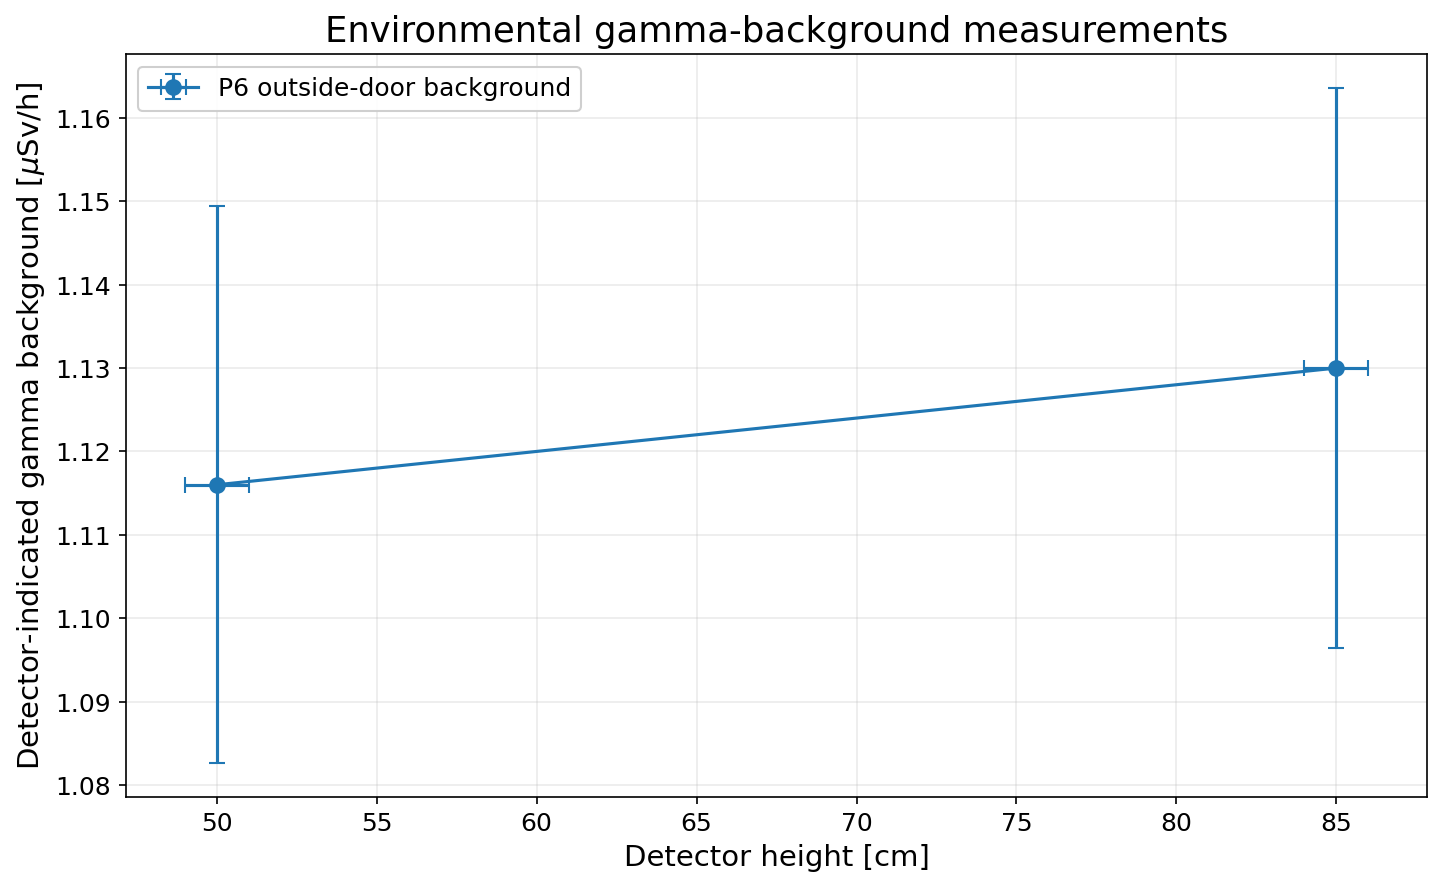

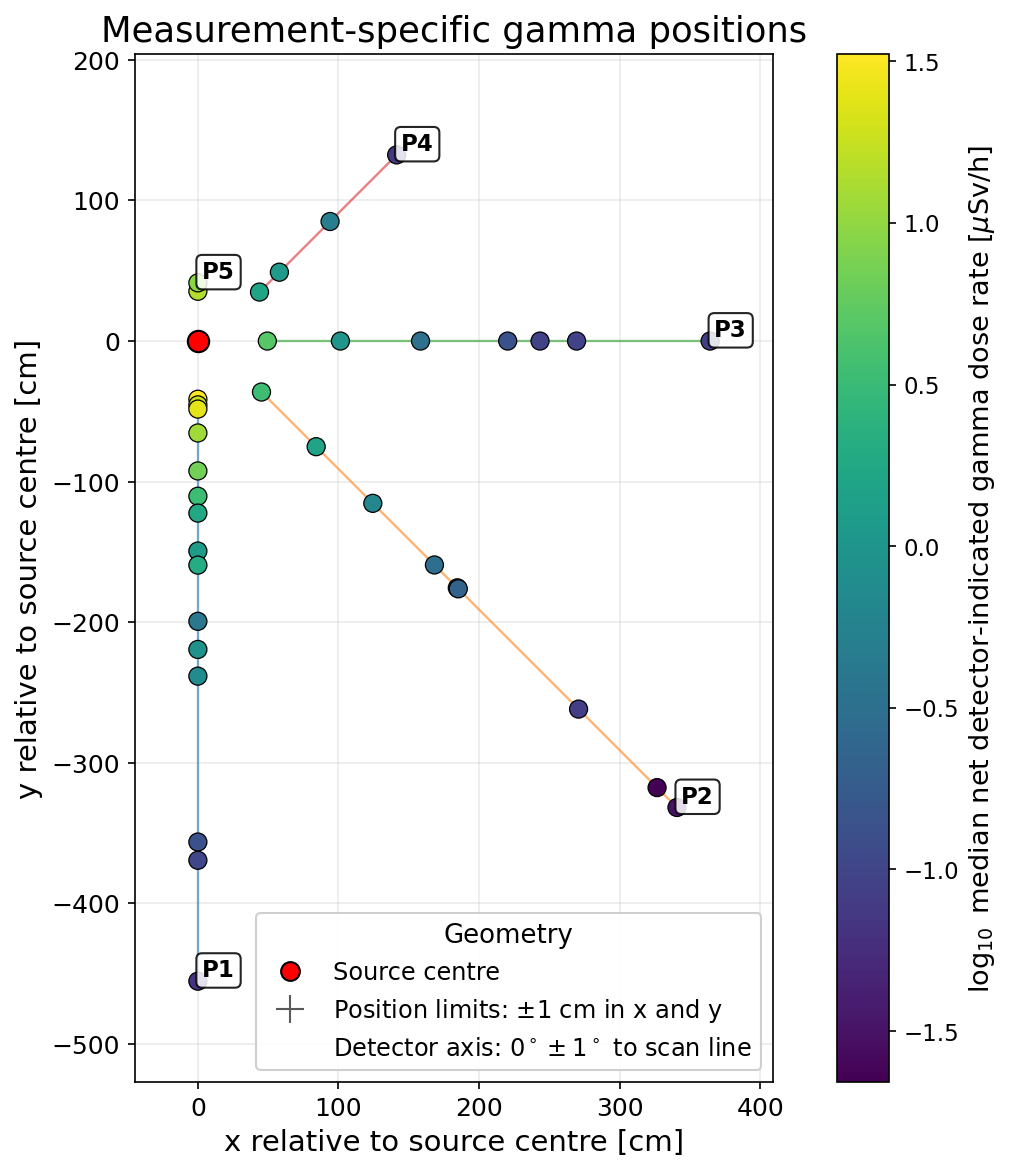

Spatial geometric limits: +/-1 cm in x, y and z; detector axis 0 +/-1 degree relative to the scan line.


In [8]:
# Environmental background and spatial-geometry dose-rate figures

exported_figure_rows = []


def save_figure(figure, filename_stem):
    png_path = FIGURE_DIR / f"{filename_stem}.png"
    pdf_path = FIGURE_DIR / f"{filename_stem}.pdf"

    figure.savefig(
        png_path,
        dpi=300,
        bbox_inches="tight",
    )
    figure.savefig(
        pdf_path,
        bbox_inches="tight",
    )

    for path in (png_path, pdf_path):
        exported_figure_rows.append(
            {
                "output_type": "figure",
                "filename": path.name,
                "path": str(path.resolve()),
                "rows": np.nan,
                "status": "exported",
            }
        )

    refresh_export_log()


def show_save_close(figure, filename_stem):
    save_figure(figure, filename_stem)
    plt.show()
    plt.close(figure)


# ------------------------------------------------------------
# Environmental gamma-background dose rate
# ------------------------------------------------------------

background_dose_plot_df = (
    measured_gamma_final_df[
        [
            "background_height_cm",
            "background_gamma_uSv_h",
            "background_gamma_uncertainty_uSv_h",
        ]
    ]
    .drop_duplicates(subset="background_height_cm")
    .sort_values("background_height_cm")
    .reset_index(drop=True)
)

background_fig, background_ax = plt.subplots(
    figsize=(9.5, 5.8),
    dpi=150,
    layout="constrained",
)

background_ax.errorbar(
    background_dose_plot_df["background_height_cm"],
    background_dose_plot_df["background_gamma_uSv_h"],
    xerr=MEASUREMENT_HEIGHT_UNCERTAINTY_CM,
    yerr=background_dose_plot_df[
        "background_gamma_uncertainty_uSv_h"
    ],
    fmt="o-",
    color="tab:blue",
    linewidth=1.5,
    markersize=7,
    capsize=4,
    label="P6 outside-door background",
)

background_ax.set_xlabel(
    "Detector height [cm]",
    fontsize=14,
)
background_ax.set_ylabel(
    r"Detector-indicated gamma background [$\mu$Sv/h]",
    fontsize=14,
)
background_ax.set_title(
    "Environmental gamma-background measurements",
    fontsize=17,
)
background_ax.tick_params(
    axis="both",
    labelsize=12,
)
background_ax.grid(
    True,
    alpha=0.25,
)
background_ax.legend(
    fontsize=12,
    title_fontsize=13,
    framealpha=0.94,
)

show_save_close(
    background_fig,
    "environmental_gamma_background",
)


# ------------------------------------------------------------
# Spatial gamma dose-rate map
# ------------------------------------------------------------

positive_geometry_df = gamma_plot_df.loc[
    gamma_plot_df["net_gamma_uSv_h"] > 0.0
].copy()

if positive_geometry_df.empty:
    raise ValueError(
        "The spatial gamma plot has no positive net dose-rate values."
    )

spatial_gamma_df = (
    positive_geometry_df
    .groupby(
        [
            "position",
            "distance_cm",
            "geometry_x_cm",
            "geometry_y_cm",
            "axis_x",
            "axis_y",
        ],
        as_index=False,
    )
    .agg(
        median_net_gamma_uSv_h=(
            "net_gamma_uSv_h",
            "median",
        ),
        median_combined_sem_gamma_uSv_h=(
            "net_gamma_uncertainty_uSv_h",
            "median",
        ),
        number_of_heights=(
            "height_cm",
            "nunique",
        ),
    )
)

spatial_gamma_df["x_position_limit_cm"] = (
    MEASUREMENT_POSITION_UNCERTAINTY_CM
)
spatial_gamma_df["y_position_limit_cm"] = (
    MEASUREMENT_POSITION_UNCERTAINTY_CM
)
spatial_gamma_df["z_position_limit_cm"] = (
    MEASUREMENT_HEIGHT_UNCERTAINTY_CM
)
spatial_gamma_df["detector_axis_alignment_deg"] = (
    GAMMA_AXIS_ALIGNMENT_DEG
)
spatial_gamma_df["detector_axis_alignment_limit_deg"] = (
    GAMMA_AXIS_ALIGNMENT_UNCERTAINTY_DEG
)

spatial_gamma_df.to_csv(
    TABLE_DIR / "12_spatial_measured_gamma_plotting_data.csv",
    index=False,
)


geometry_fig, geometry_ax = plt.subplots(
    figsize=(8.7, 7.7),
    dpi=150,
    layout="constrained",
)

for position, group in spatial_gamma_df.groupby(
    "position",
    sort=True,
):
    group = group.sort_values("distance_cm")

    geometry_ax.plot(
        group["geometry_x_cm"],
        group["geometry_y_cm"],
        color=POSITION_COLORS[position],
        linewidth=1.1,
        alpha=0.6,
        zorder=2,
    )

    geometry_ax.errorbar(
        group["geometry_x_cm"],
        group["geometry_y_cm"],
        xerr=group["x_position_limit_cm"],
        yerr=group["y_position_limit_cm"],
        fmt="none",
        ecolor="0.35",
        elinewidth=1.0,
        capsize=3,
        alpha=0.65,
        zorder=3,
    )

    label_row = group.iloc[-1]

    geometry_ax.text(
        label_row["geometry_x_cm"] + 3.0,
        label_row["geometry_y_cm"] + 3.0,
        position,
        fontsize=11,
        fontweight="bold",
        bbox={
            "boxstyle": "round,pad=0.25",
            "facecolor": "white",
            "edgecolor": "black",
            "alpha": 0.86,
        },
        zorder=6,
    )


geometry_scatter = geometry_ax.scatter(
    spatial_gamma_df["geometry_x_cm"],
    spatial_gamma_df["geometry_y_cm"],
    c=np.log10(
        spatial_gamma_df["median_net_gamma_uSv_h"]
    ),
    s=75,
    edgecolor="black",
    linewidth=0.6,
    zorder=4,
)

geometry_ax.scatter(
    [0.0],
    [0.0],
    s=105,
    color="red",
    edgecolor="black",
    zorder=5,
)

geometry_colorbar = geometry_fig.colorbar(
    geometry_scatter,
    ax=geometry_ax,
)
geometry_colorbar.set_label(
    r"$\log_{10}$ median net detector-indicated gamma dose rate "
    r"[$\mu$Sv/h]",
    fontsize=13,
)
geometry_colorbar.ax.tick_params(
    labelsize=11,
)

geometry_ax.set_xlabel(
    "x relative to source centre [cm]",
    fontsize=14,
)
geometry_ax.set_ylabel(
    "y relative to source centre [cm]",
    fontsize=14,
)
geometry_ax.set_title(
    "Measurement-specific gamma positions",
    fontsize=17,
)
geometry_ax.tick_params(
    axis="both",
    labelsize=12,
)
geometry_ax.set_aspect(
    "equal",
    adjustable="box",
)
geometry_ax.margins(0.12)

geometry_ax.legend(
    handles=[
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor="red",
            markeredgecolor="black",
            markersize=9,
            label="Source centre",
        ),
        Line2D(
            [0],
            [0],
            marker="+",
            color="0.35",
            linestyle="none",
            markersize=13,
            label=r"Position limits: $\pm1$ cm in x and y",
        ),
        Line2D(
            [0],
            [0],
            color="none",
            linestyle="none",
            label=(
                r"Detector axis: $0^\circ\pm1^\circ$ "
                r"to scan line"
            ),
        ),
    ],
    loc="best",
    fontsize=11.5,
    title="Geometry",
    title_fontsize=12.5,
    framealpha=0.94,
)

show_save_close(
    geometry_fig,
    "measured_gamma_geometry_xy",
)

print(
    "Spatial geometric limits: +/-1 cm in x, y and z; "
    "detector axis 0 +/-1 degree relative to the scan line."
)

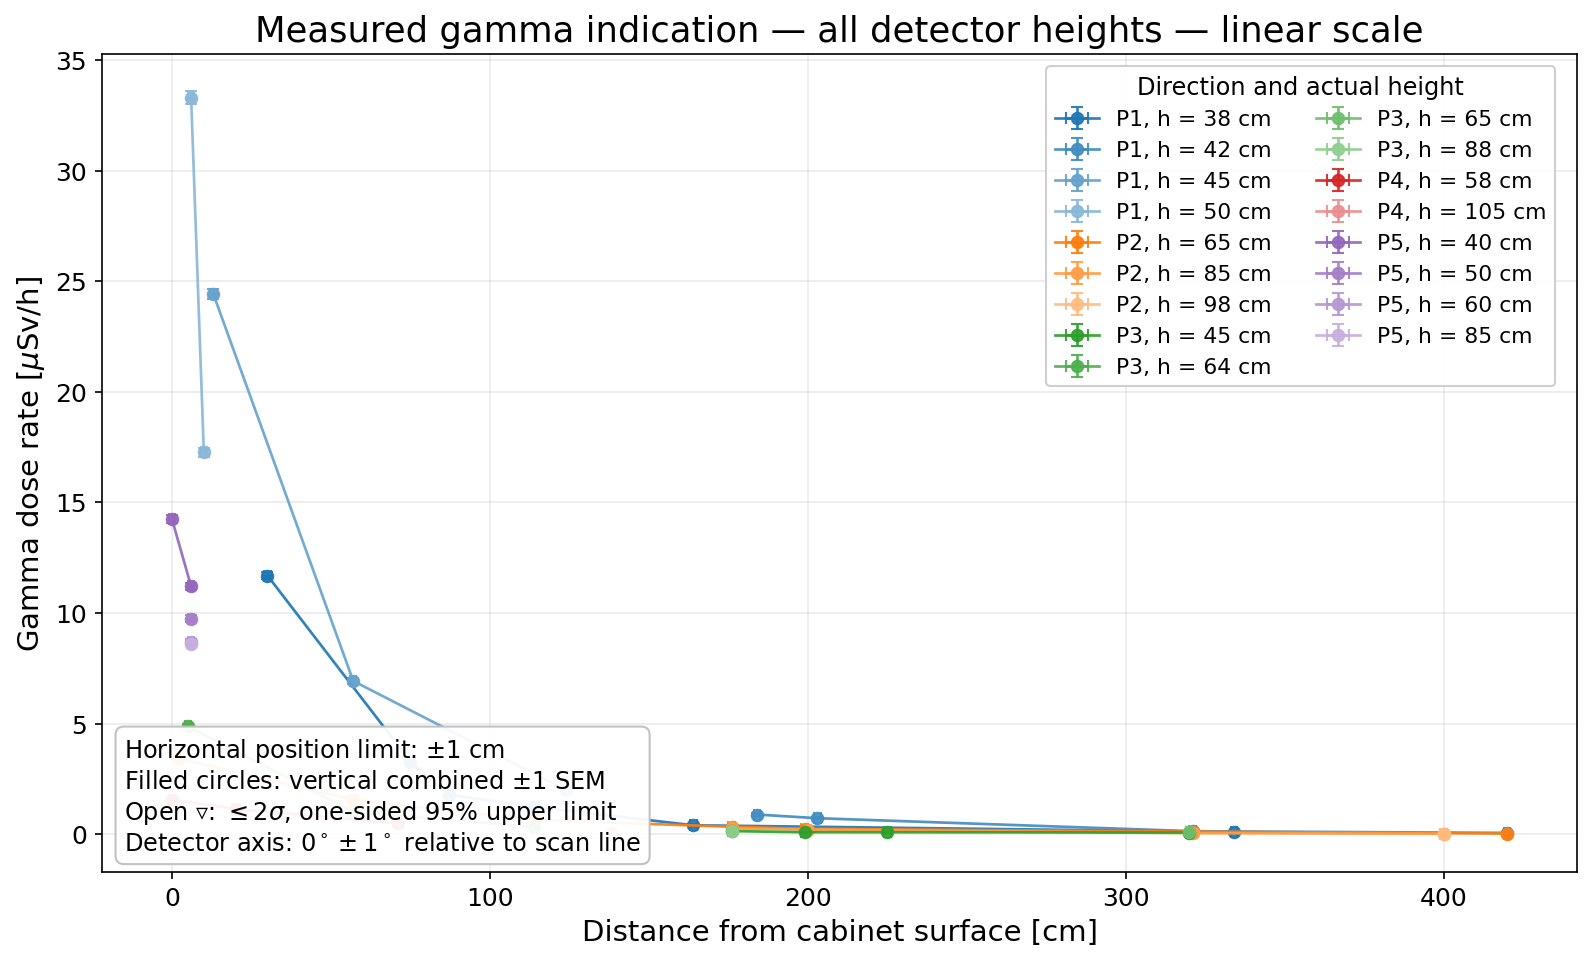

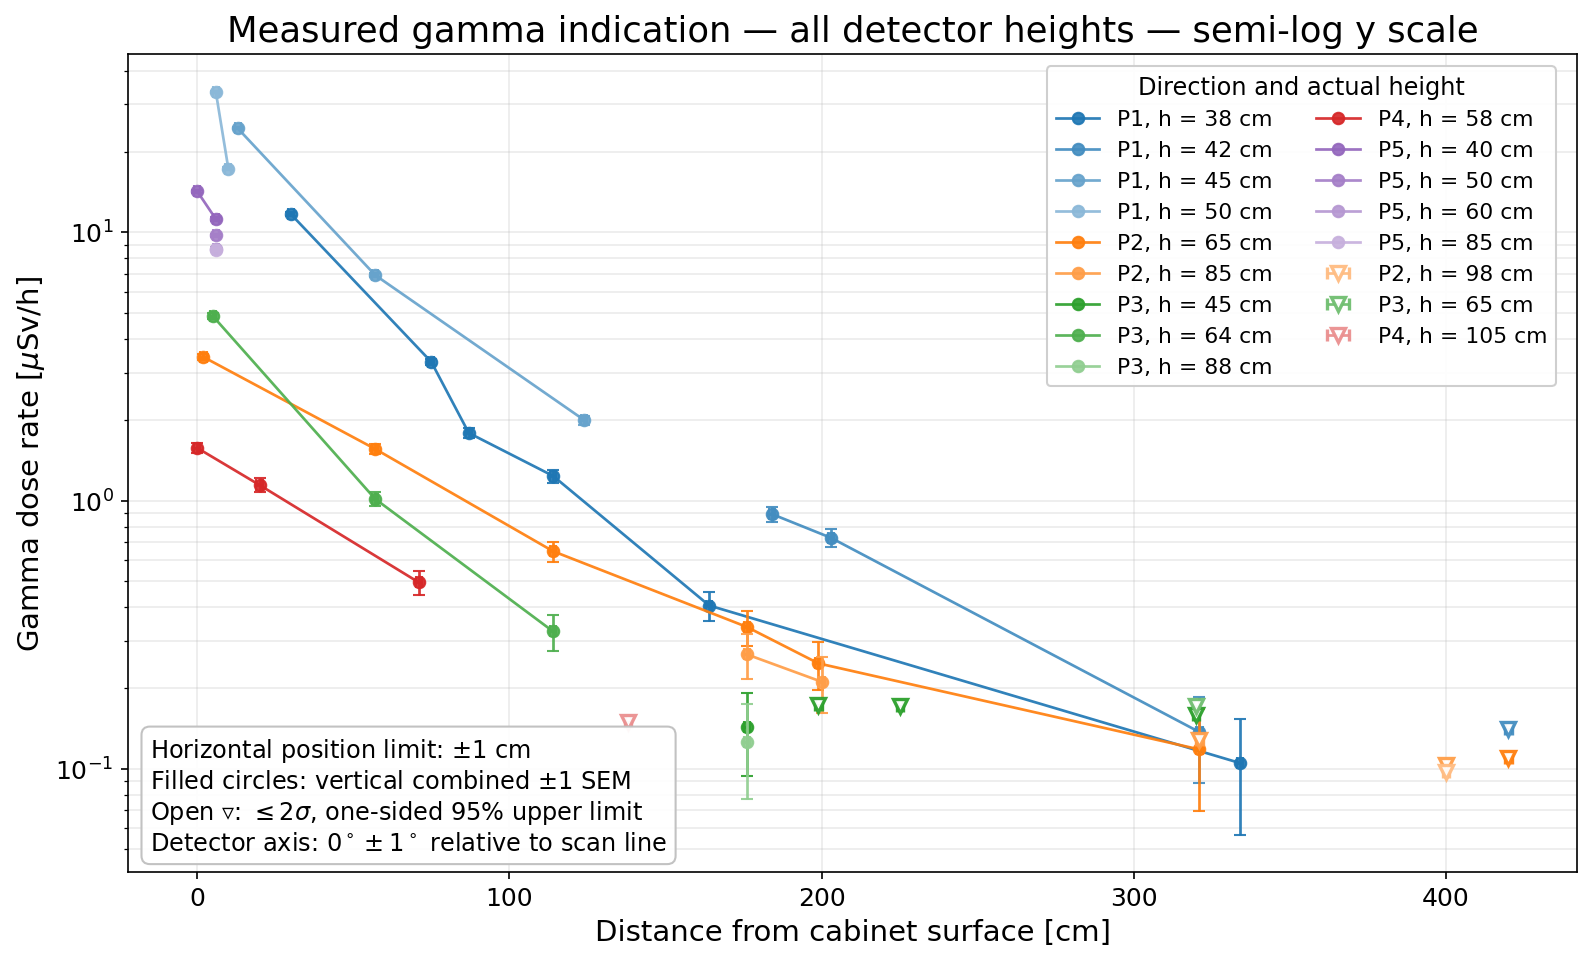

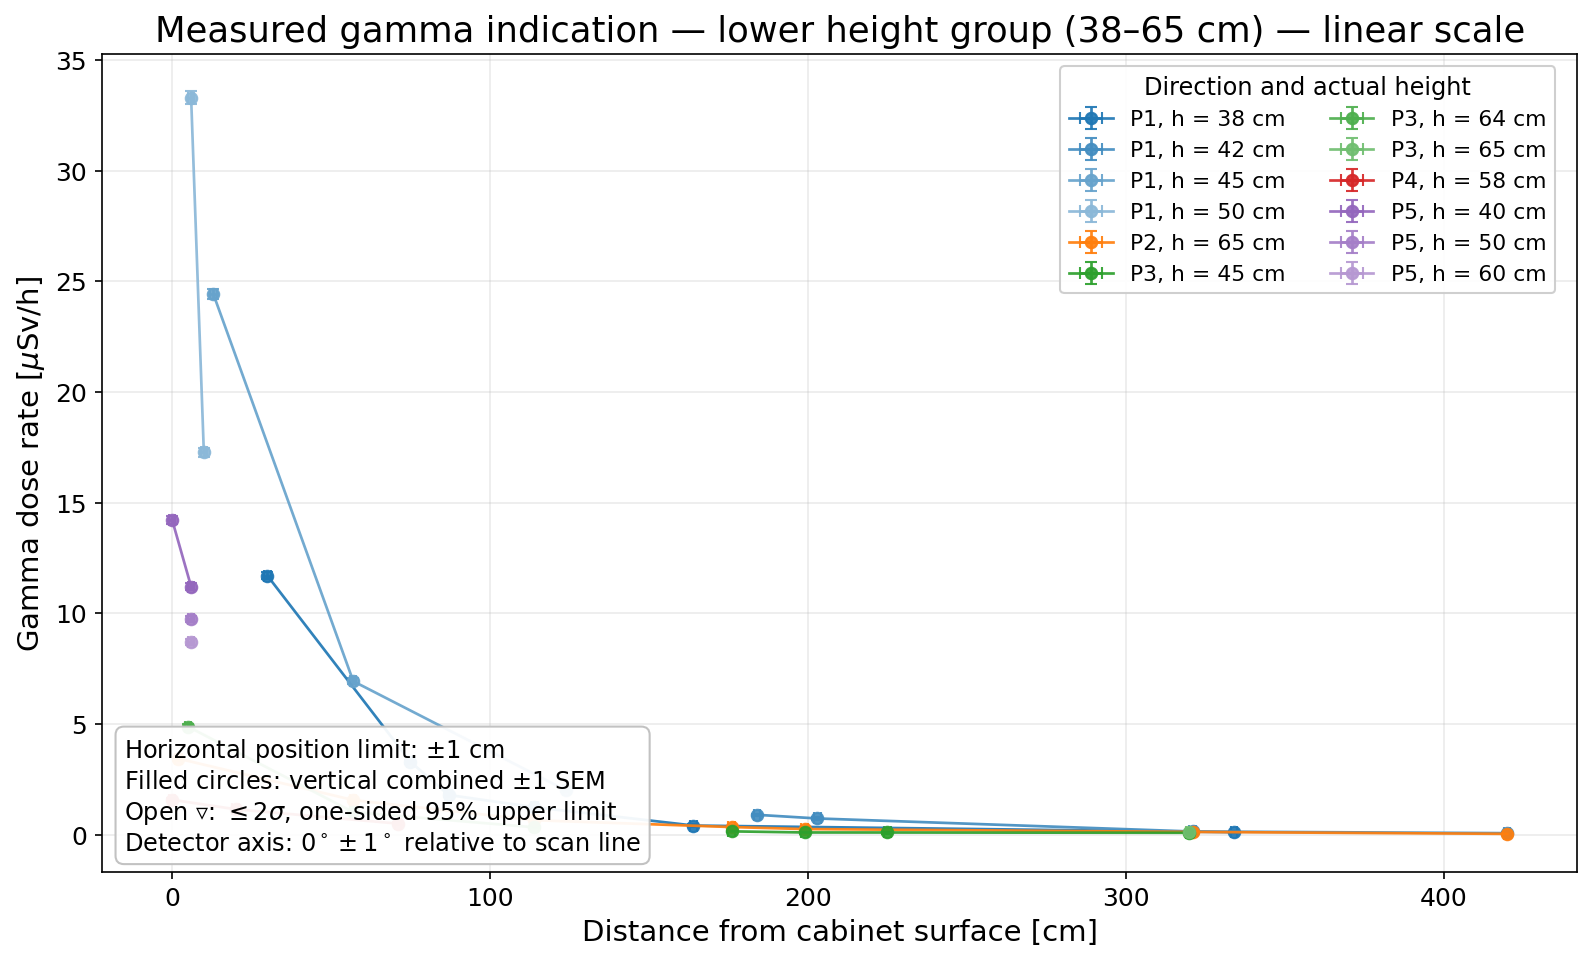

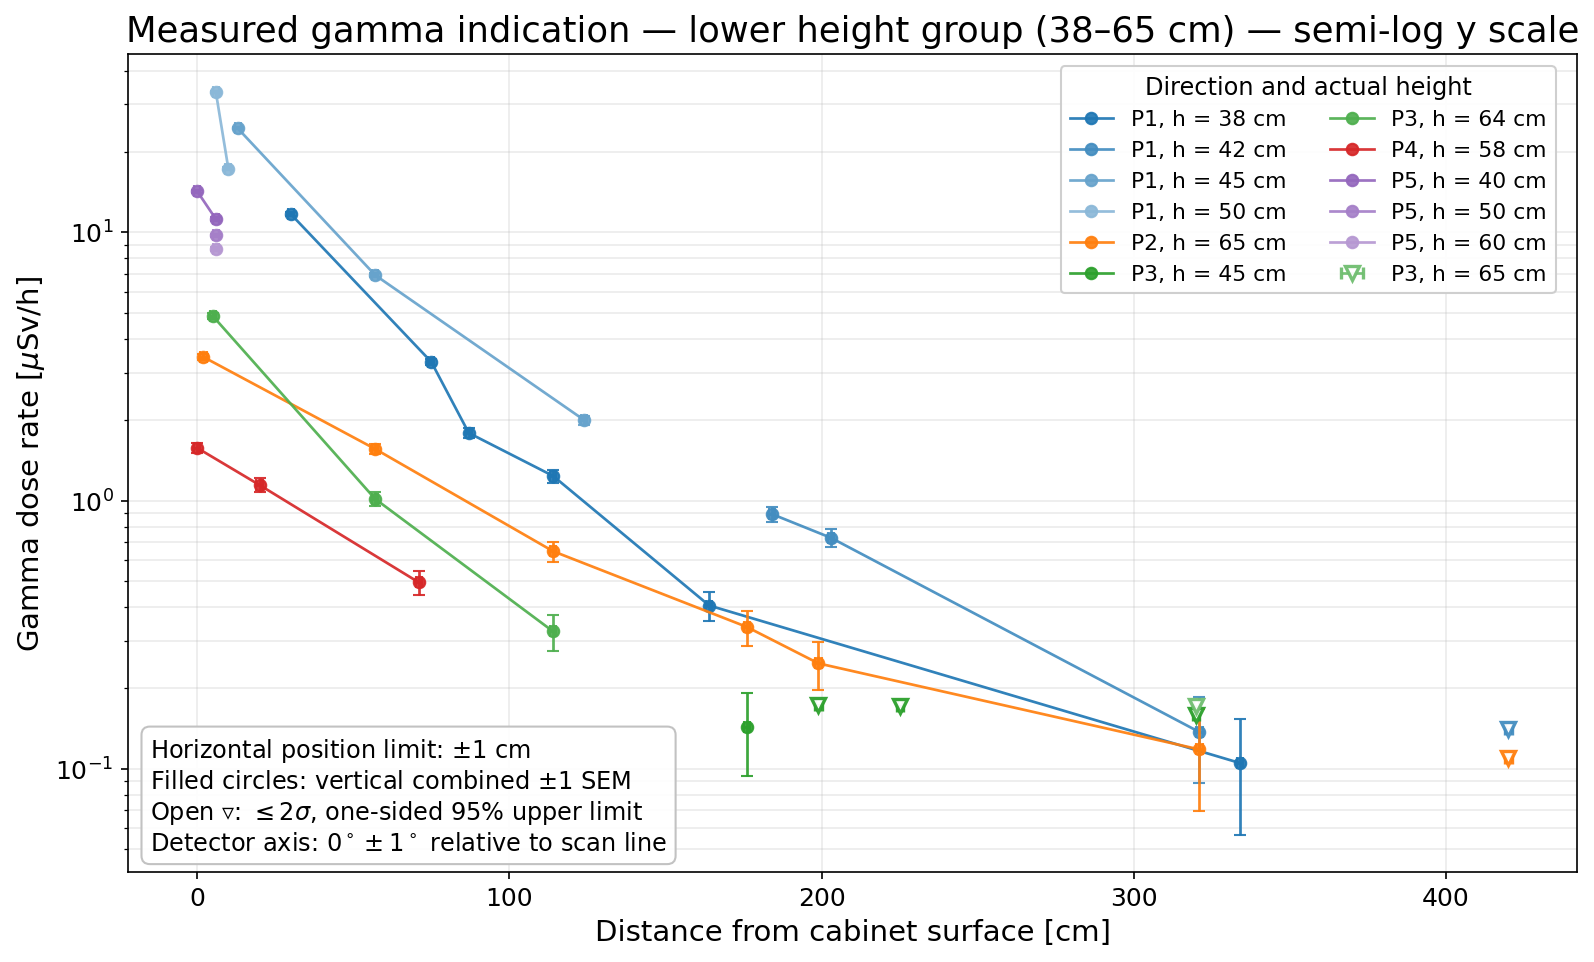

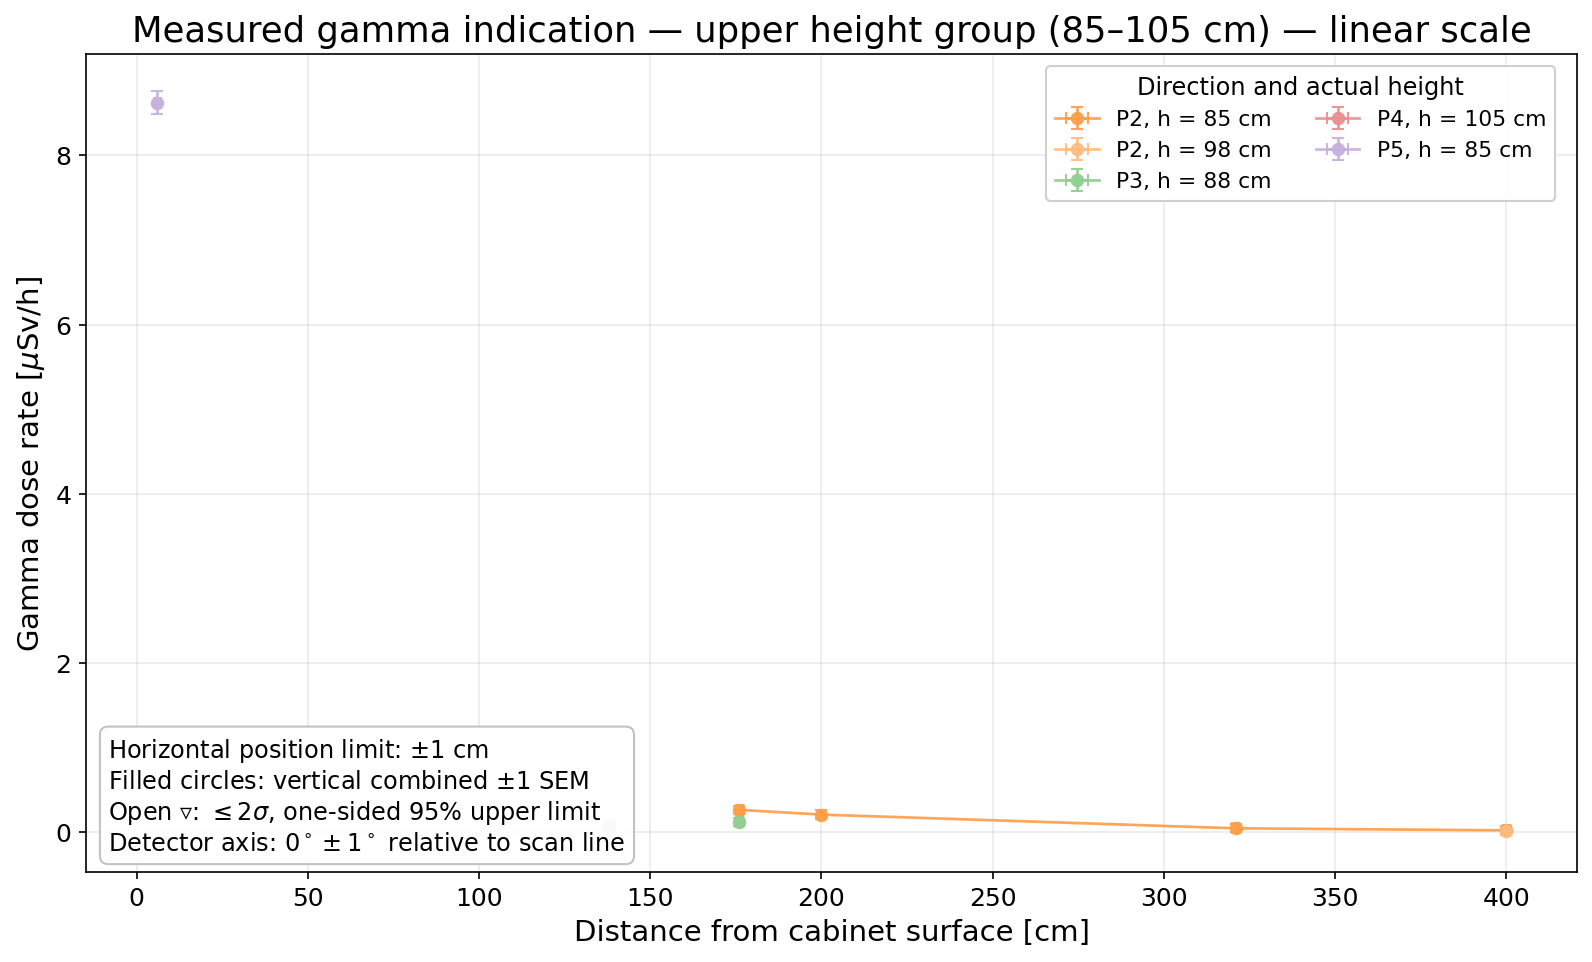

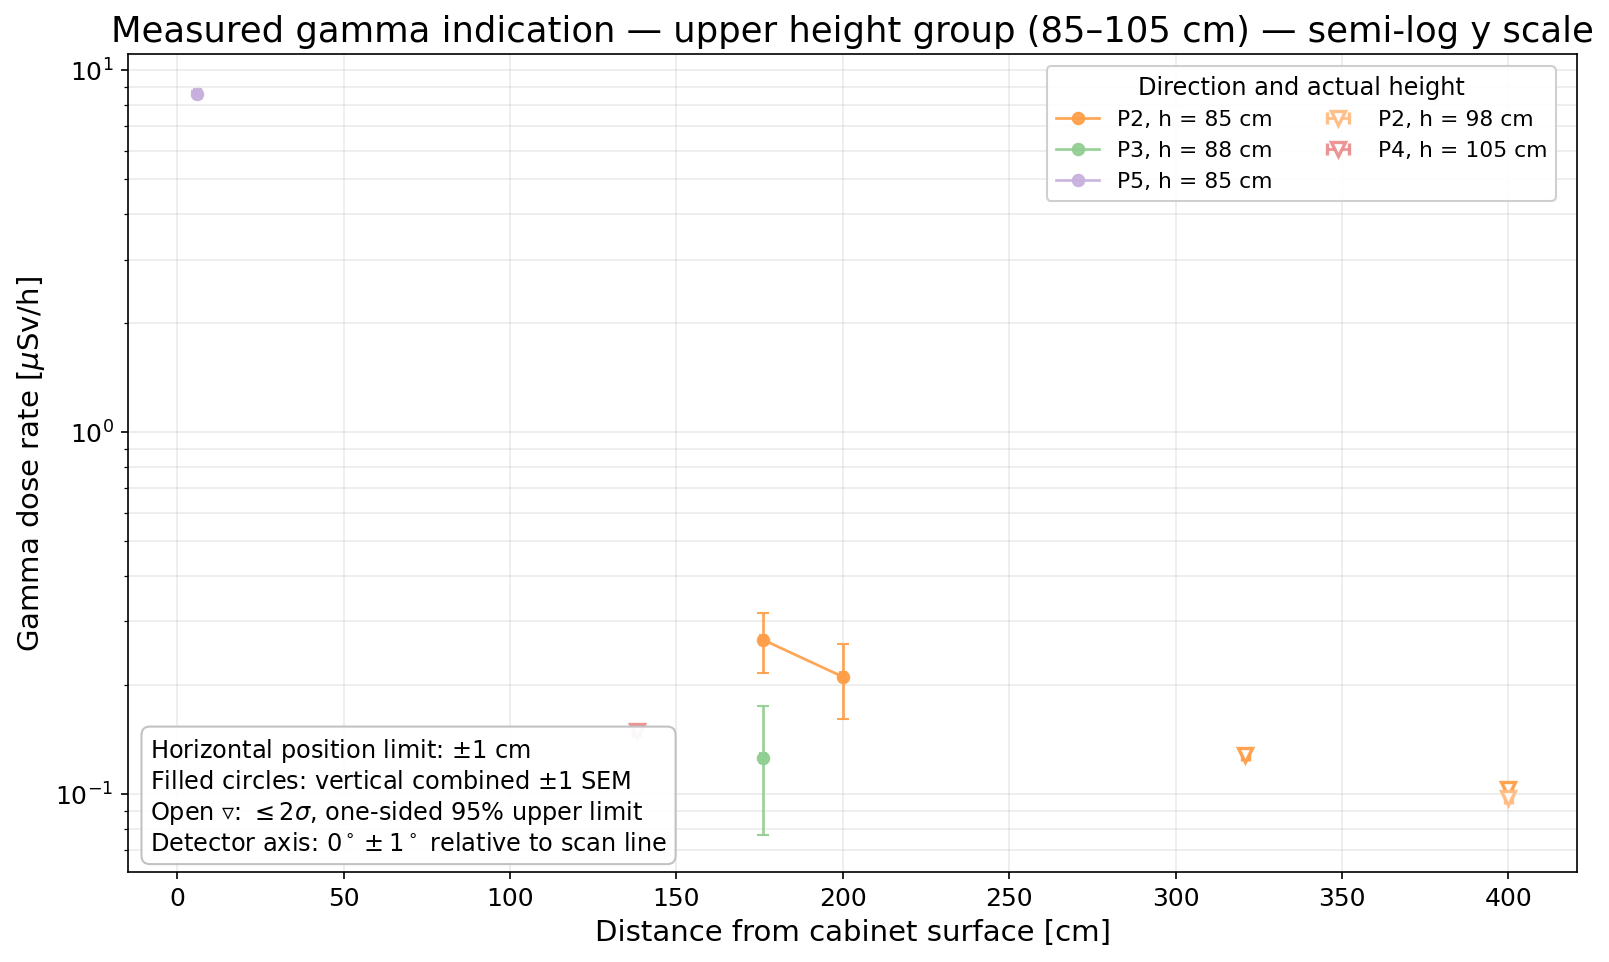

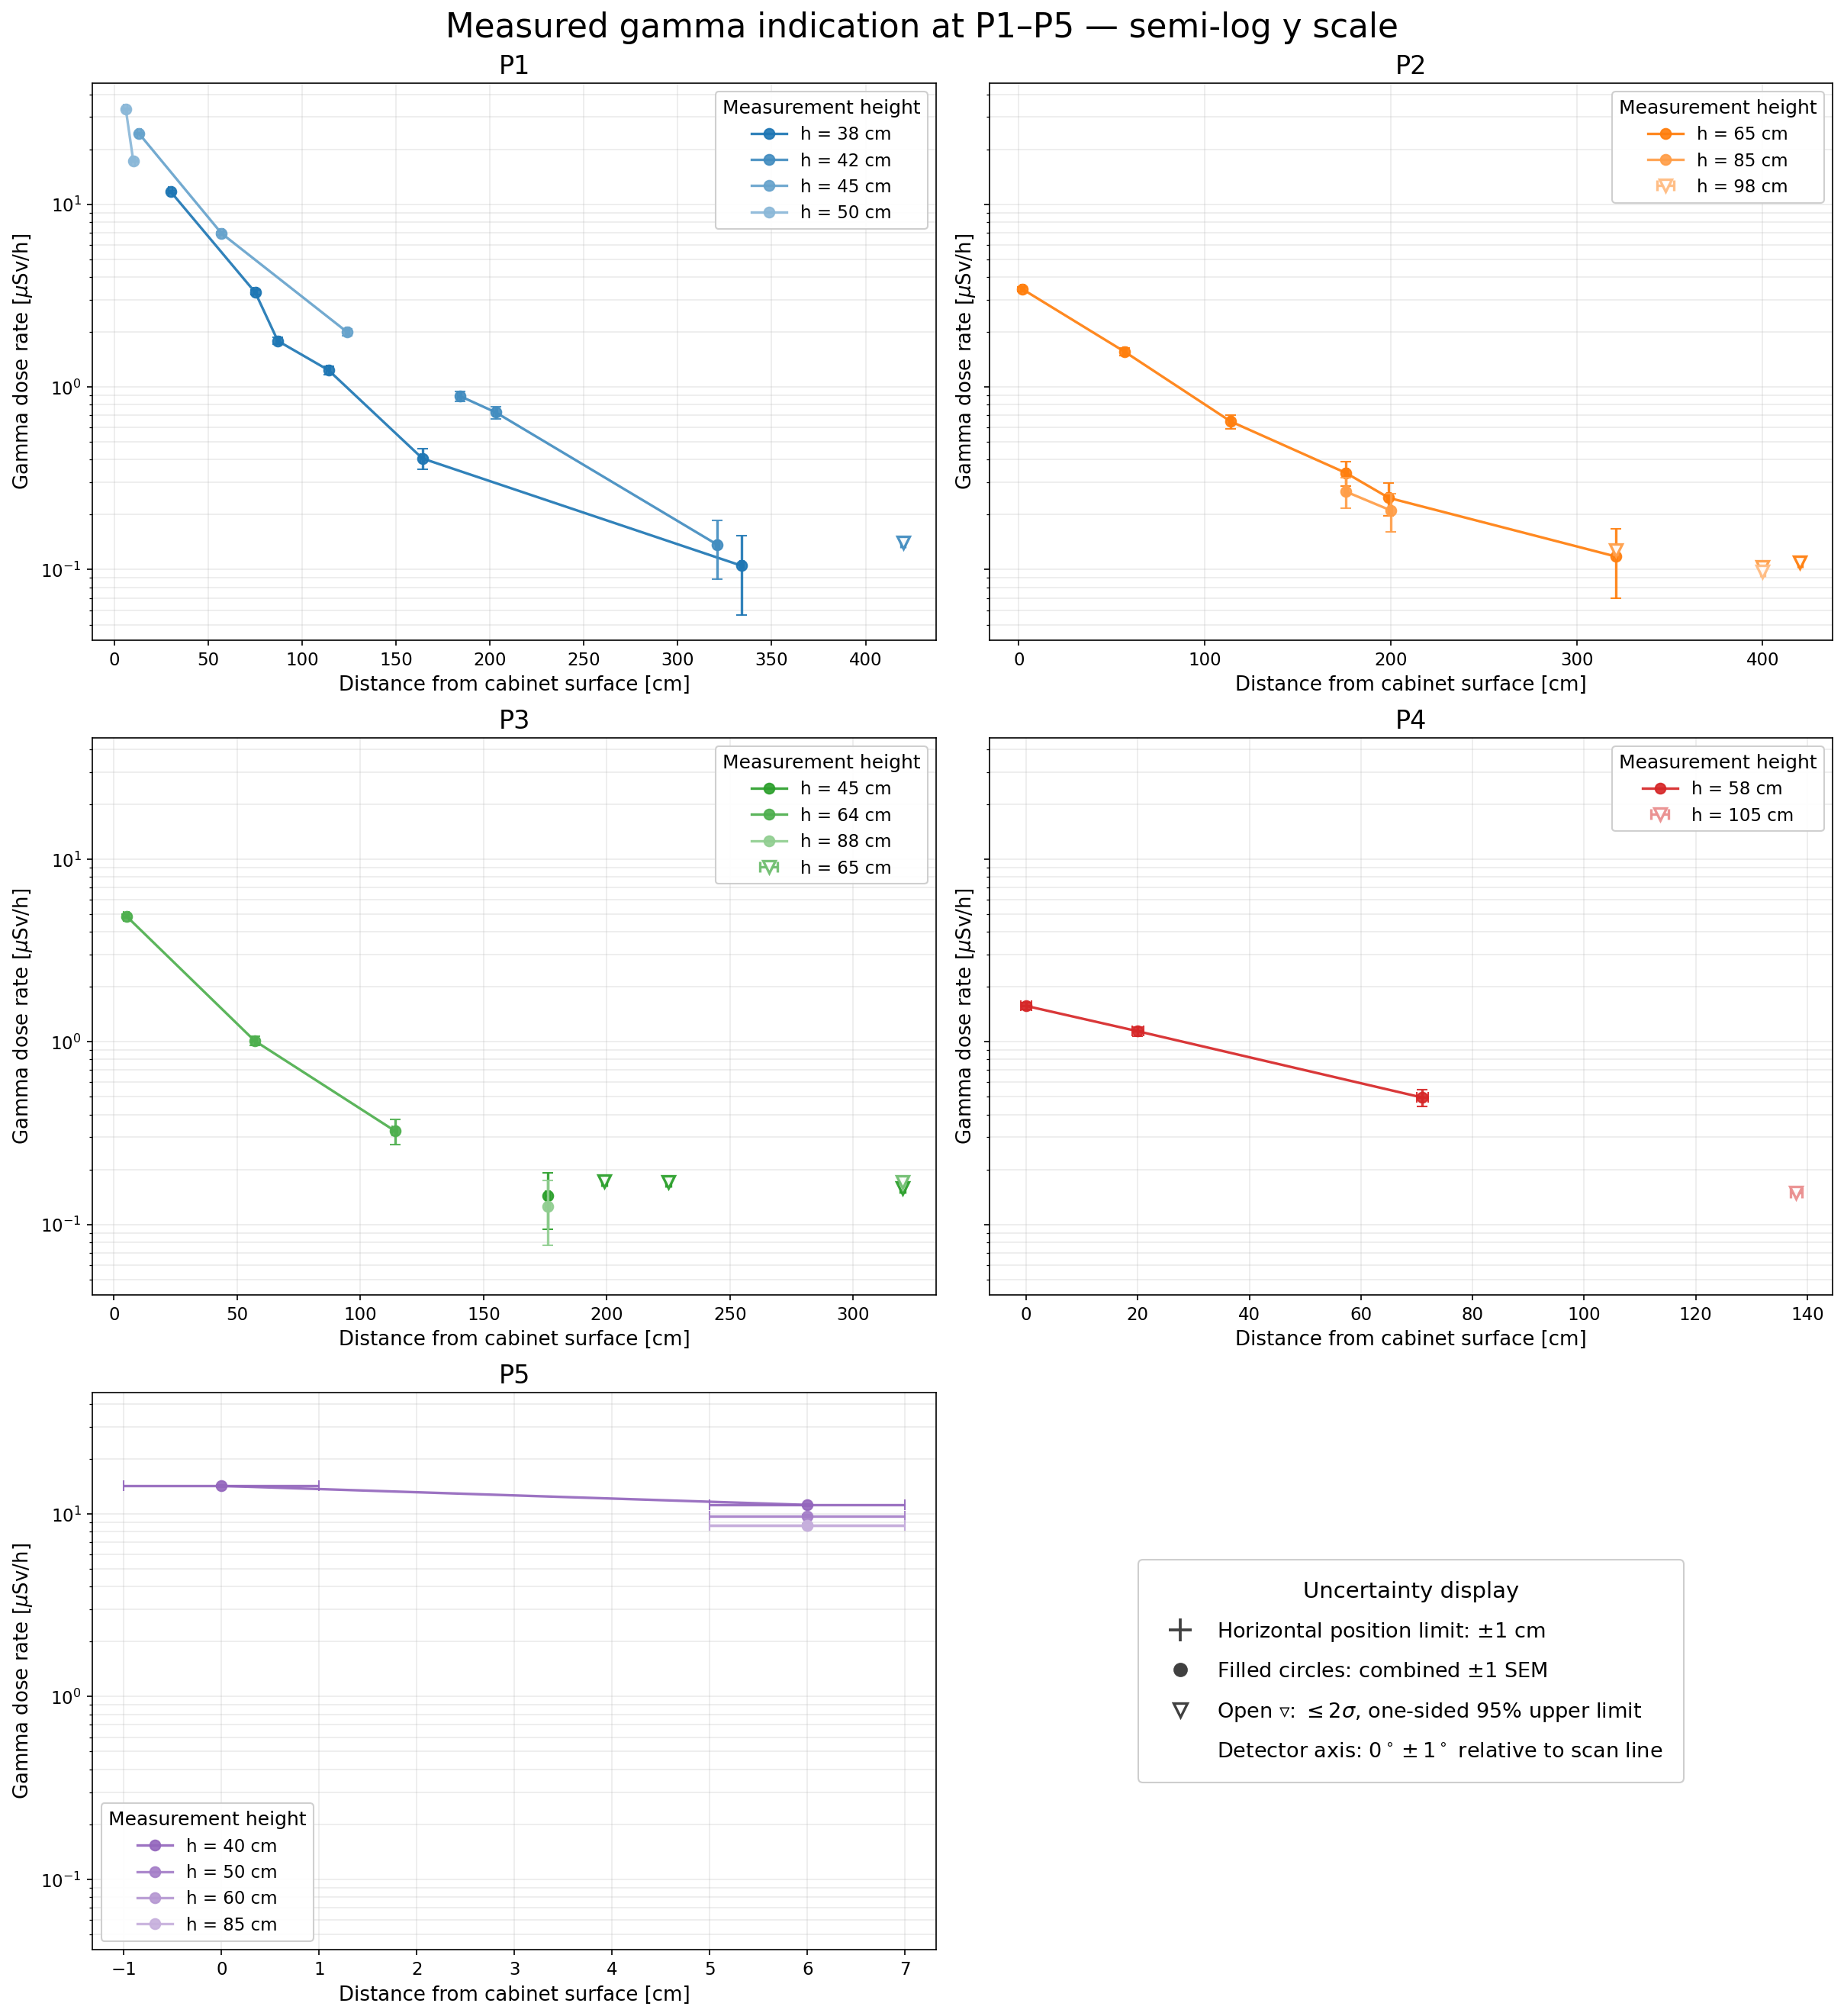

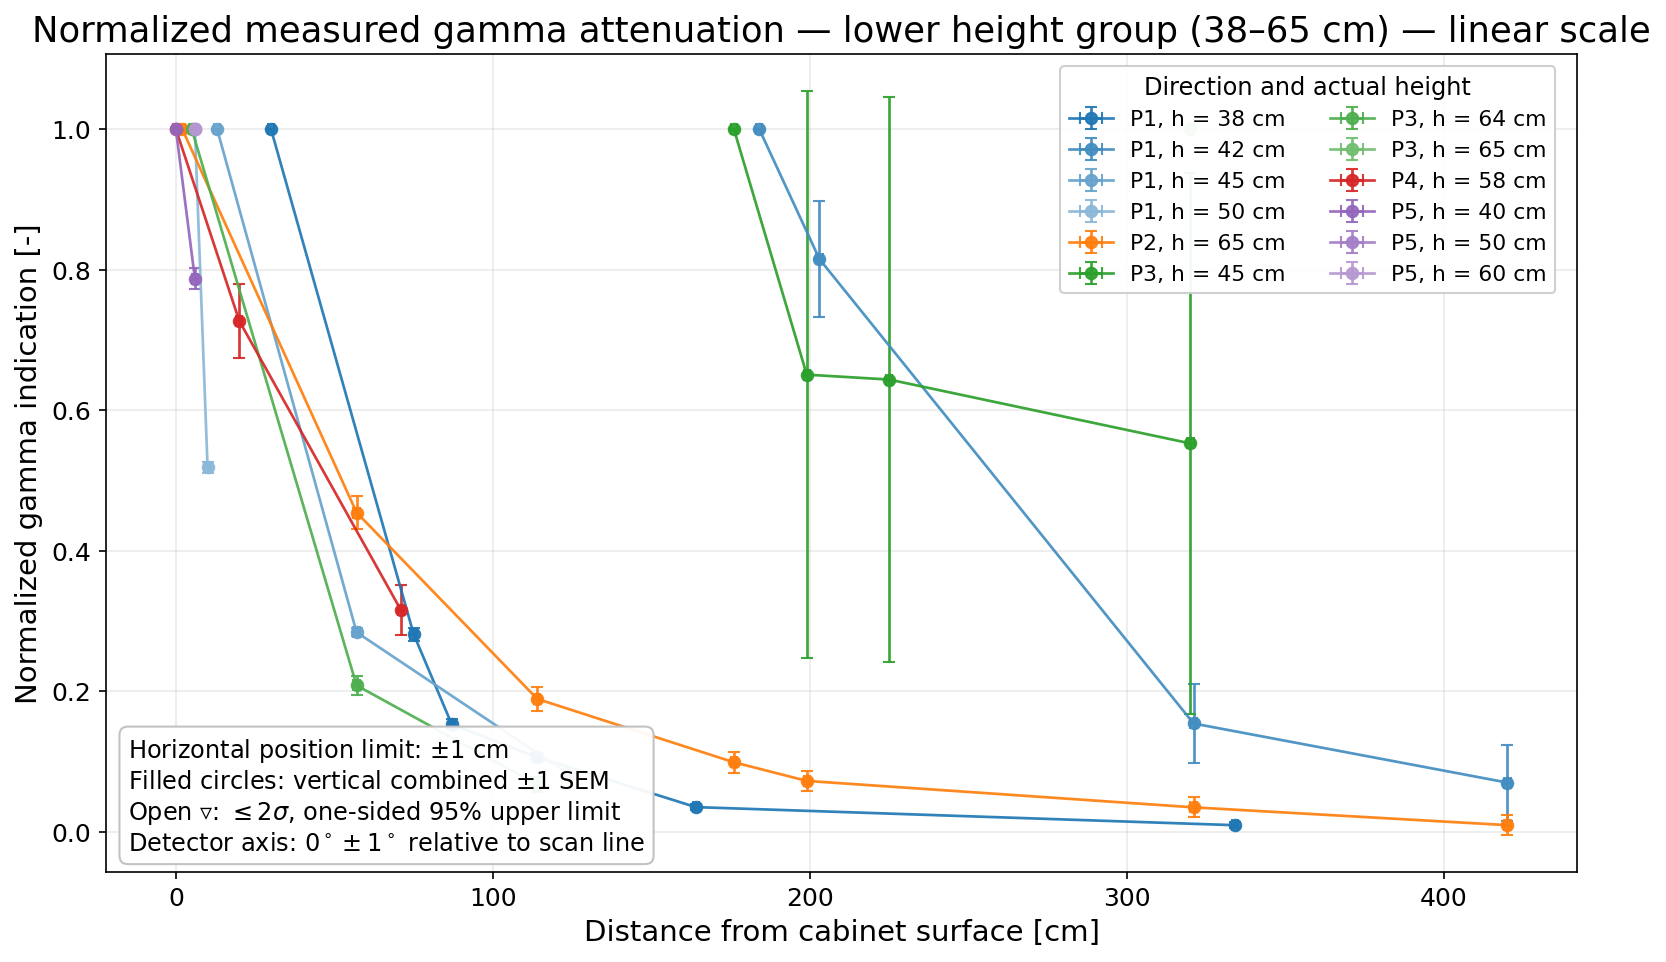

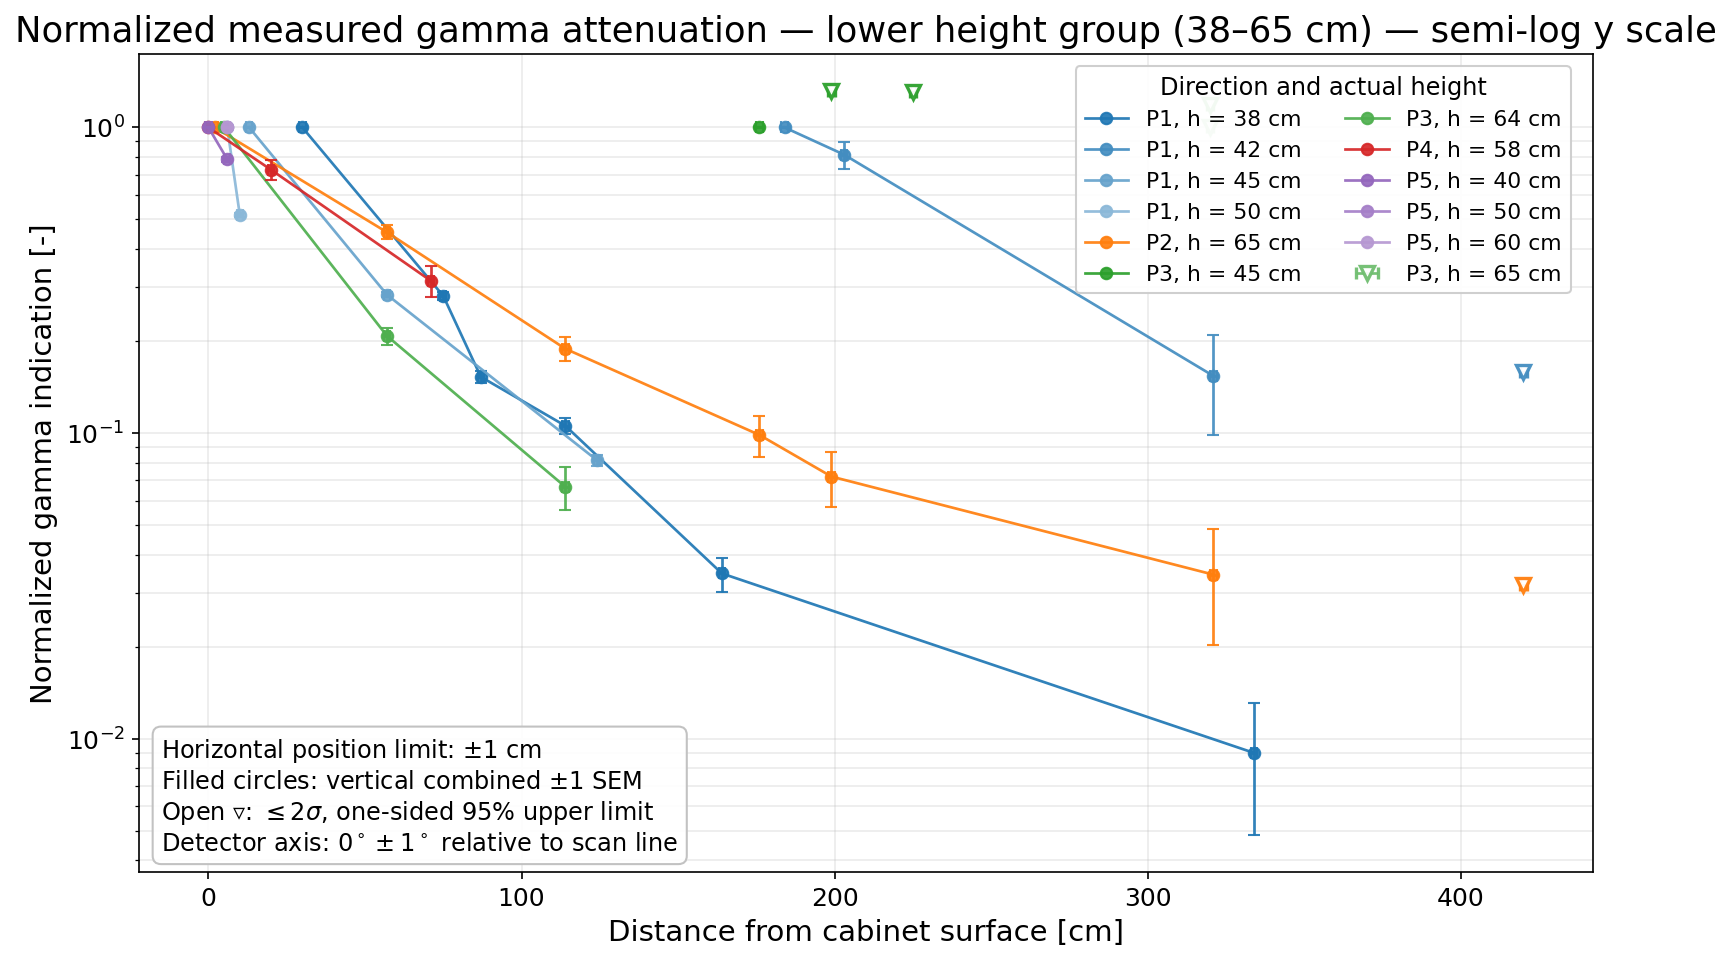

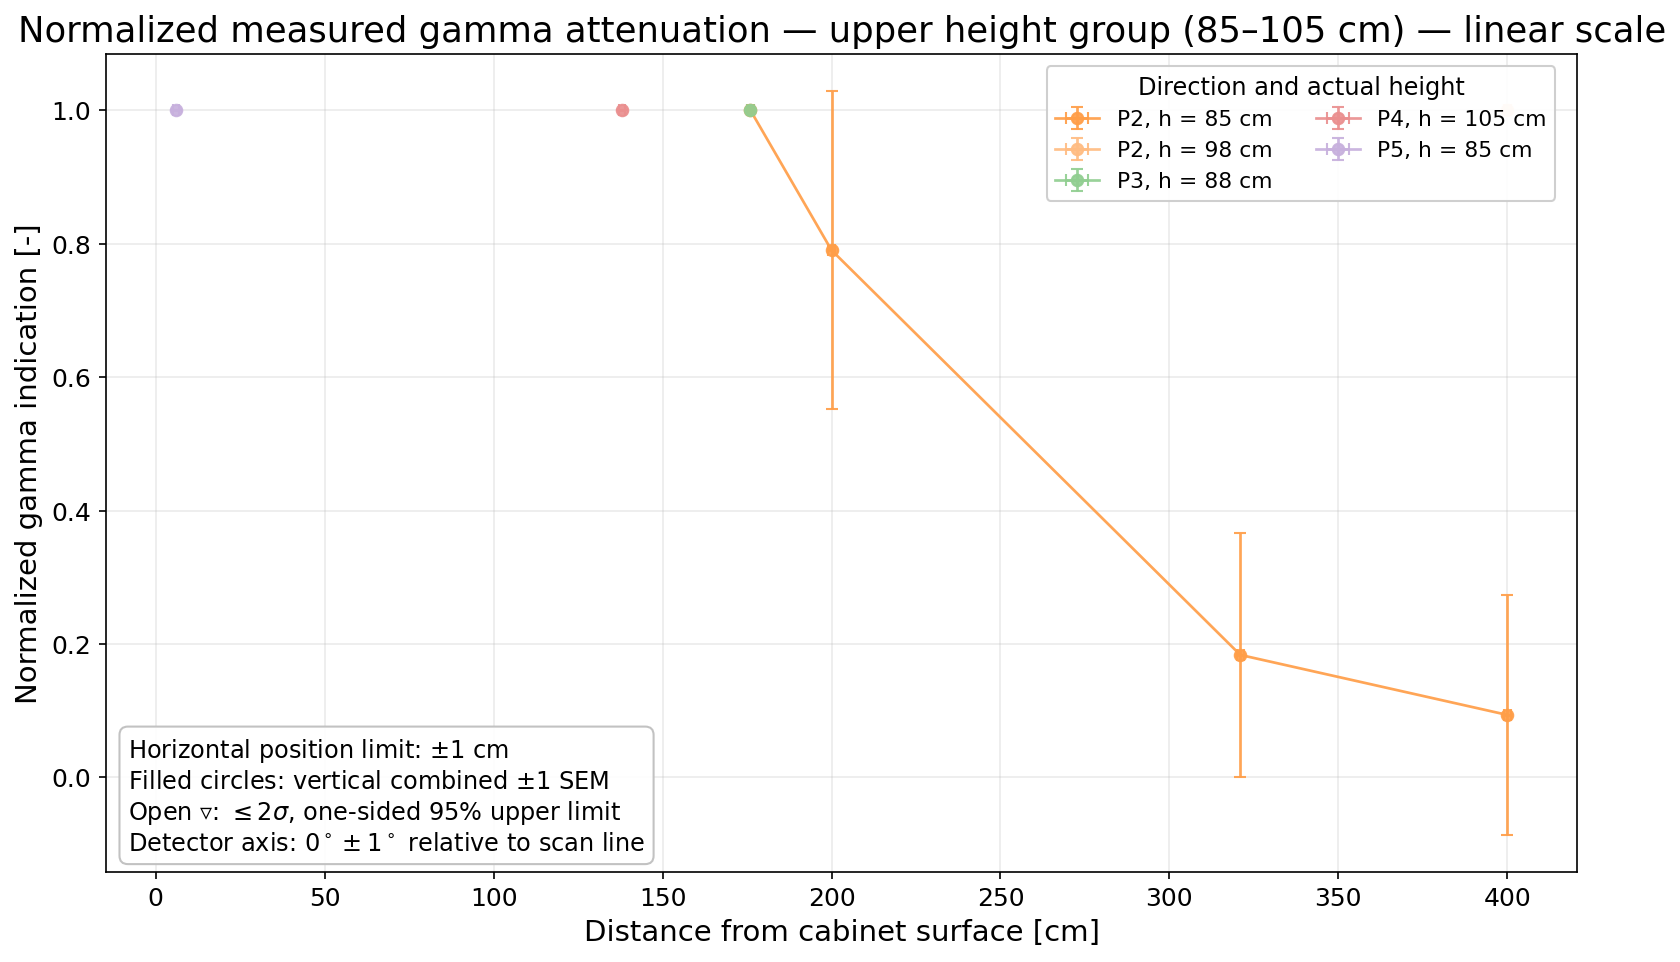

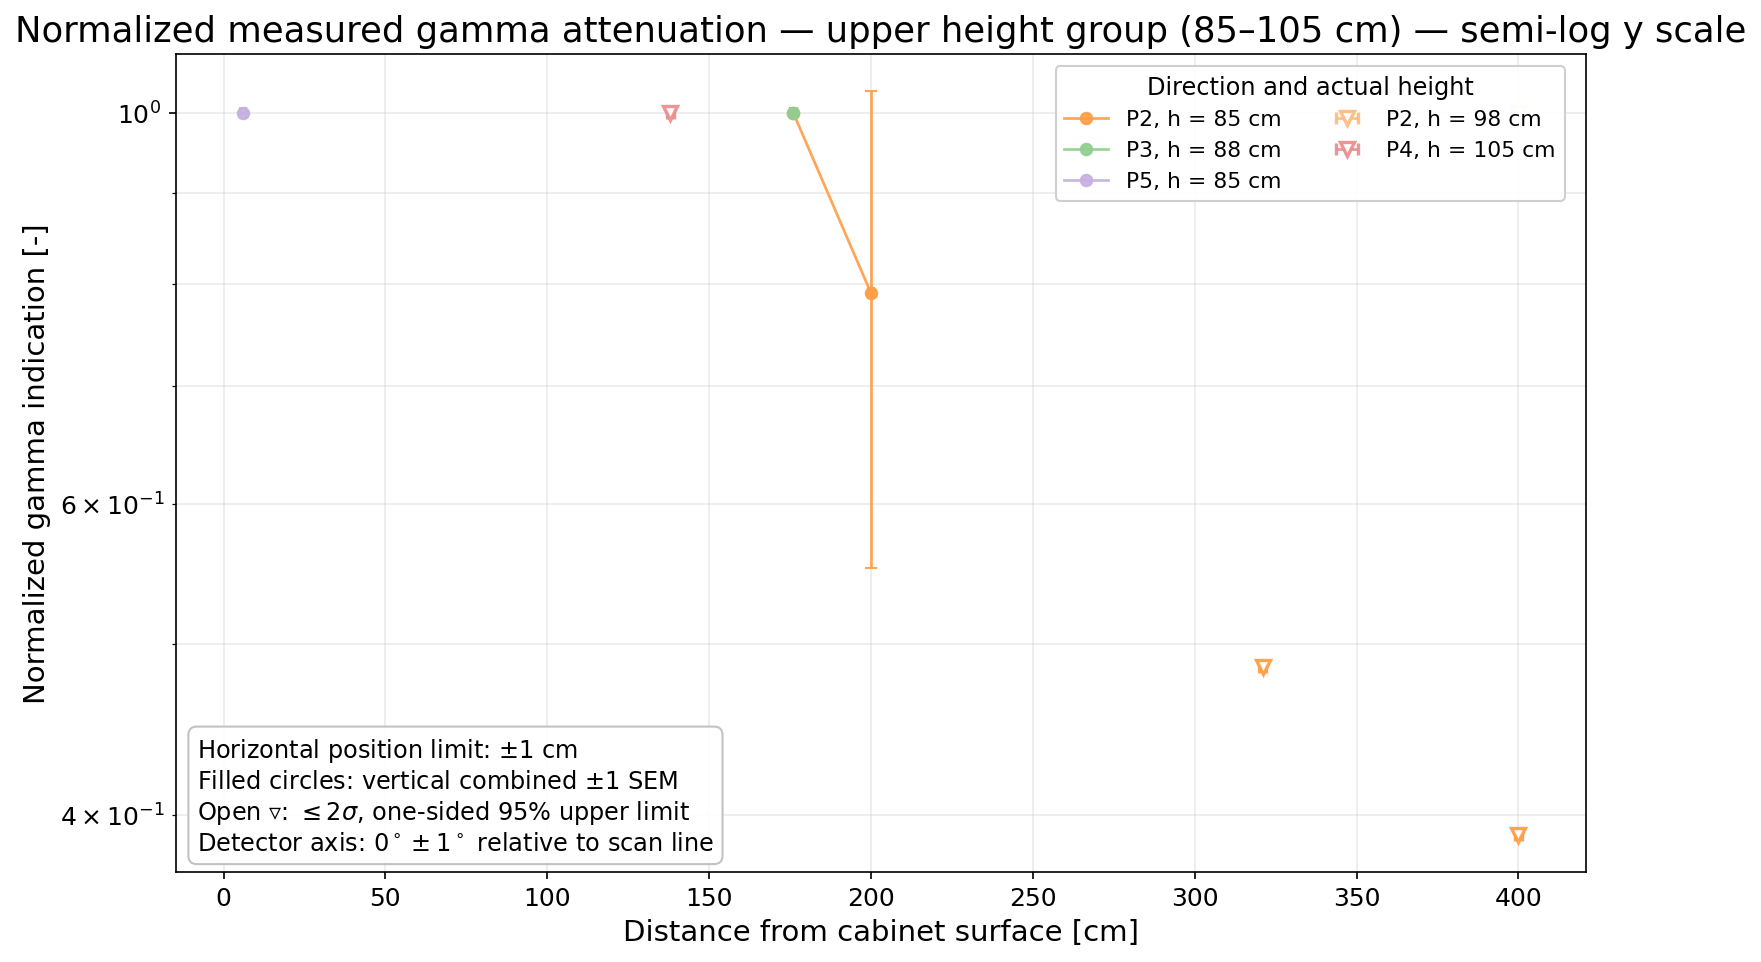

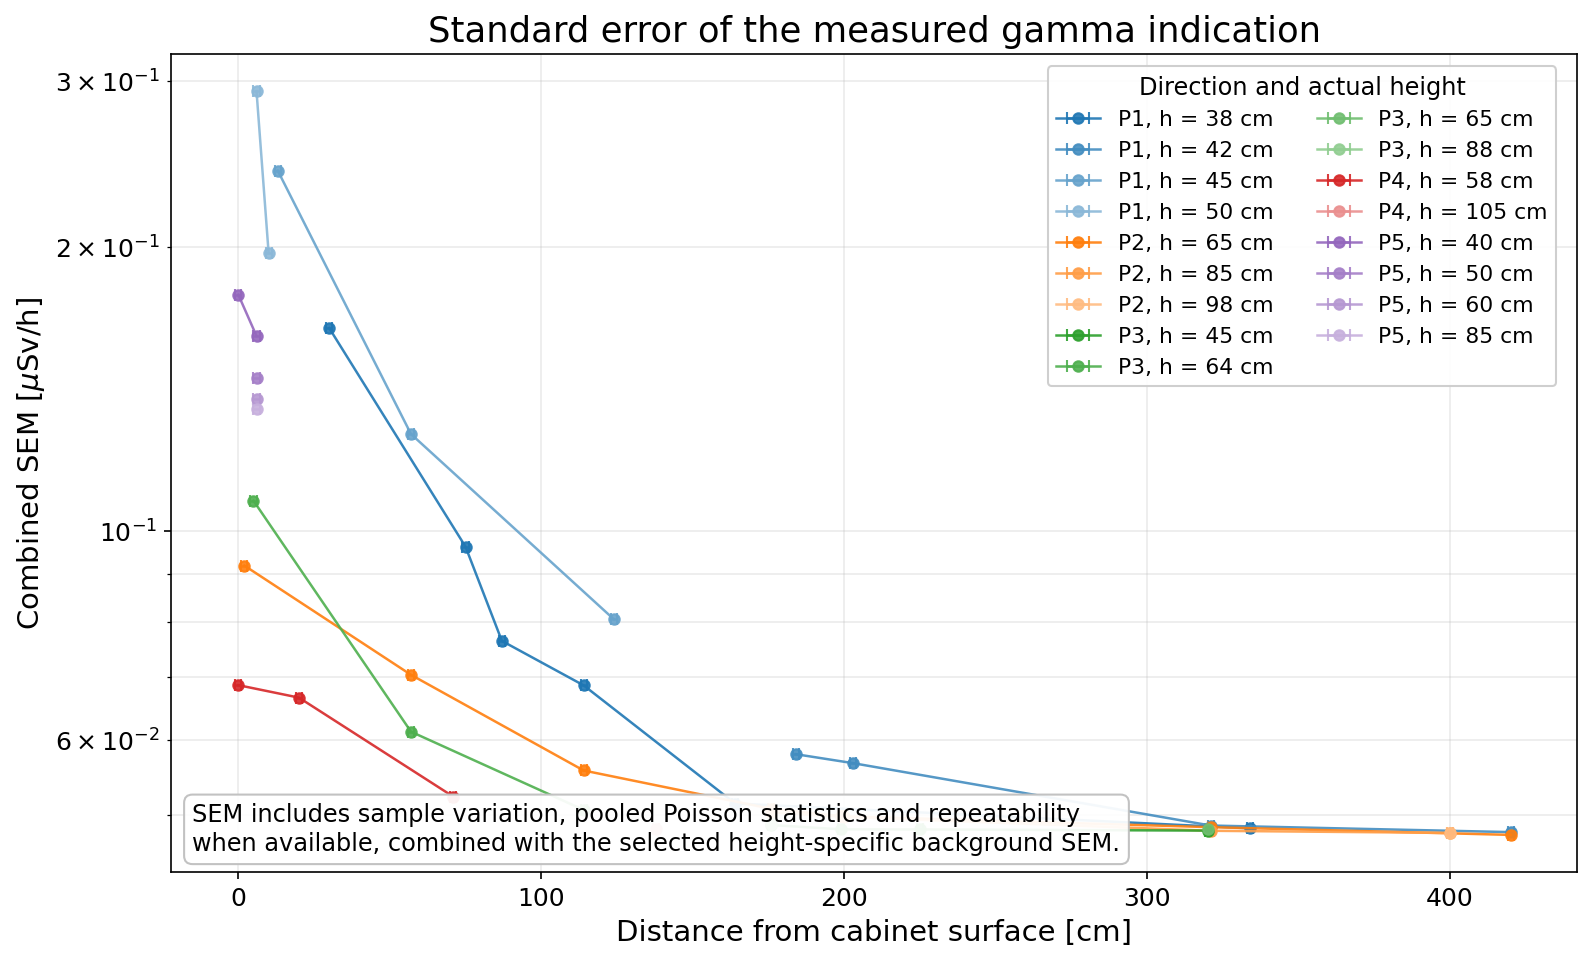

Saved figure files: 100
Figure folder: /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N4_5_measured_gamma_outputs/figures


In [13]:
# Dose-rate, attenuation, semi-log, position-panel and SEM figures

ONE_SIDED_95_Z = 1.6448536269514722


def log_safe_yerr(mean, uncertainty):
    mean = np.asarray(mean, dtype=float)
    uncertainty = np.asarray(uncertainty, dtype=float)

    lower = np.minimum(
        uncertainty,
        np.maximum(mean * (1.0 - 1.0e-6), 0.0),
    )
    return np.vstack([lower, uncertainty])


FIGURE_TITLE_FONTSIZE = 17
FIGURE_SUPTITLE_FONTSIZE = 21
FIGURE_LABEL_FONTSIZE = 14
FIGURE_TICK_FONTSIZE = 12
FIGURE_LEGEND_FONTSIZE = 10.5
FIGURE_LEGEND_TITLE_FONTSIZE = 11.5
FIGURE_NOTE_FONTSIZE = 11.5


def style_axis_text(
    axis,
    title_size=FIGURE_TITLE_FONTSIZE,
    label_size=FIGURE_LABEL_FONTSIZE,
    tick_size=FIGURE_TICK_FONTSIZE,
):
    axis.title.set_fontsize(title_size)
    axis.xaxis.label.set_size(label_size)
    axis.yaxis.label.set_size(label_size)
    axis.tick_params(
        axis="both",
        which="both",
        labelsize=tick_size,
    )


def uncertainty_note(axis):
    lines = [
        r"Horizontal position limit: $\pm1$ cm",
        r"Filled circles: vertical combined $\pm1$ SEM",
        r"Open $\triangledown$: $\leq2\sigma$, one-sided 95% upper limit",
        r"Detector axis: $0^\circ\pm1^\circ$ relative to scan line",
    ]

    axis.text(
        0.015,
        0.02,
        "\n".join(lines),
        transform=axis.transAxes,
        fontsize=FIGURE_NOTE_FONTSIZE,
        va="bottom",
        ha="left",
        linespacing=1.25,
        zorder=20,
        bbox={
            "boxstyle": "round,pad=0.35",
            "facecolor": "white",
            "edgecolor": "0.75",
            "alpha": 0.94,
        },
    )


POSITION_HEIGHT_COLOURS = make_position_height_colors(gamma_plot_df)


def prepare_curve(
    group,
    value_column,
    uncertainty_column,
):
    group = group.sort_values("distance_cm").copy()

    x = group["distance_cm"].to_numpy(dtype=float)
    y = group[value_column].to_numpy(dtype=float)
    uncertainty = group[uncertainty_column].to_numpy(dtype=float)

    valid = (
        np.isfinite(x)
        & np.isfinite(y)
        & np.isfinite(uncertainty)
        & (uncertainty >= 0.0)
    )

    if "above_background_2sigma" in group.columns:
        detected = (
            group["above_background_2sigma"]
            .fillna(False)
            .to_numpy(dtype=bool)
        )
    else:
        detected = y > (2.0 * uncertainty)

    return x, y, uncertainty, valid, detected


def add_gamma_curve(
    axis,
    group,
    value_column,
    uncertainty_column,
    color,
    label,
    y_scale="linear",
    linewidth=1.3,
    markersize=5.5,
    capsize=3.0,
):
    x, y, uncertainty, valid, detected = prepare_curve(
        group,
        value_column,
        uncertainty_column,
    )

    if y_scale == "linear":
        if not np.any(valid):
            return False

        axis.errorbar(
            x[valid],
            y[valid],
            xerr=np.full(
                np.count_nonzero(valid),
                MEASUREMENT_POSITION_UNCERTAINTY_CM,
            ),
            yerr=uncertainty[valid],
            fmt="o-",
            linewidth=linewidth,
            markersize=markersize,
            capsize=capsize,
            color=color,
            alpha=0.92,
            label=label,
            zorder=3,
        )
        return True

    detected = valid & detected & (y > 0.0)

    upper_limit = y + ONE_SIDED_95_Z * uncertainty
    upper_limit_point = (
        valid
        & ~detected
        & np.isfinite(upper_limit)
        & (upper_limit > 0.0)
    )

    if not np.any(detected) and not np.any(upper_limit_point):
        return False

    if np.any(detected):
        # NaN values break the line at points represented by upper limits.
        line_y = np.full_like(y, np.nan, dtype=float)
        line_y[detected] = y[detected]

        axis.plot(
            x,
            line_y,
            marker="o",
            linestyle="-",
            linewidth=linewidth,
            markersize=markersize,
            color=color,
            alpha=0.92,
            label=label,
            zorder=3,
        )

        axis.errorbar(
            x[detected],
            y[detected],
            xerr=np.full(
                np.count_nonzero(detected),
                MEASUREMENT_POSITION_UNCERTAINTY_CM,
            ),
            yerr=log_safe_yerr(
                y[detected],
                uncertainty[detected],
            ),
            fmt="none",
            ecolor=color,
            elinewidth=linewidth,
            capsize=capsize,
            alpha=0.92,
            zorder=3,
        )

    if np.any(upper_limit_point):
        upper_limit_label = (
            label if not np.any(detected) else "_nolegend_"
        )

        axis.errorbar(
            x[upper_limit_point],
            upper_limit[upper_limit_point],
            xerr=np.full(
                np.count_nonzero(upper_limit_point),
                MEASUREMENT_POSITION_UNCERTAINTY_CM,
            ),
            fmt="v",
            linestyle="none",
            markersize=markersize + 1.2,
            markerfacecolor="white",
            markeredgecolor=color,
            markeredgewidth=1.6,
            ecolor=color,
            elinewidth=linewidth,
            capsize=capsize,
            color=color,
            alpha=0.95,
            label=upper_limit_label,
            zorder=4,
        )

    return True


def format_curve_axis(
    axis,
    xlabel,
    ylabel,
    title,
    y_scale,
    legend_title="Direction and actual height",
    legend_ncol=2,
    include_uncertainty_note=True,
):
    if y_scale == "log":
        axis.set_yscale("log")

    axis.set_xlabel(xlabel)
    axis.set_ylabel(ylabel)
    axis.set_title(title)
    axis.grid(True, which="both", alpha=0.25)
    style_axis_text(axis)

    axis.legend(
        title=legend_title,
        loc="upper right",
        bbox_to_anchor=(0.985, 0.985),
        borderaxespad=0.0,
        ncol=legend_ncol,
        fontsize=FIGURE_LEGEND_FONTSIZE,
        title_fontsize=FIGURE_LEGEND_TITLE_FONTSIZE,
        frameon=True,
        framealpha=0.94,
        facecolor="white",
    )

    if include_uncertainty_note:
        uncertainty_note(axis)


def plot_gamma_dose_rate(
    dataframe,
    title,
    filename_stem,
    y_scale="linear",
):
    if y_scale not in {"linear", "log"}:
        raise ValueError("y_scale must be 'linear' or 'log'.")

    figure, axis = plt.subplots(
        figsize=(10.5, 6.3),
        dpi=150,
        layout="constrained",
    )

    for (position, height_cm), group in dataframe.groupby(
        ["position", "height_cm"],
        sort=True,
    ):
        add_gamma_curve(
            axis=axis,
            group=group,
            value_column="net_gamma_uSv_h",
            uncertainty_column="net_gamma_uncertainty_uSv_h",
            color=POSITION_HEIGHT_COLOURS[
                (position, float(height_cm))
            ],
            label=f"{position}, h = {height_cm:g} cm",
            y_scale=y_scale,
        )

    scale_text = (
        "semi-log y scale"
        if y_scale == "log"
        else "linear scale"
    )

    format_curve_axis(
        axis=axis,
        xlabel="Distance from cabinet surface [cm]",
        ylabel=(
            r"Gamma dose rate "
            r"[$\mu$Sv/h]"
        ),
        title=f"{title} — {scale_text}",
        y_scale=y_scale,
    )

    show_save_close(figure, filename_stem)


dose_plot_specs = [
    (
        gamma_plot_df,
        "Measured gamma indication — all detector heights",
        "measured_gamma_dose_rate_all_points",
    ),
    (
        lower_height_gamma_df,
        "Measured gamma indication — "
        f"{GAMMA_HEIGHT_GROUP_LABELS['lower'].lower()}",
        "measured_gamma_dose_rate_lower_height",
    ),
    (
        upper_height_gamma_df,
        "Measured gamma indication — "
        f"{GAMMA_HEIGHT_GROUP_LABELS['upper'].lower()}",
        "measured_gamma_dose_rate_upper_height",
    ),
]

for dose_dataframe, dose_title, dose_stem in dose_plot_specs:
    plot_gamma_dose_rate(
        dose_dataframe,
        dose_title,
        f"{dose_stem}_linear",
        y_scale="linear",
    )
    plot_gamma_dose_rate(
        dose_dataframe,
        dose_title,
        dose_stem,
        y_scale="log",
    )


# ------------------------------------------------------------
# One semi-log panel for each measurement position
# ------------------------------------------------------------

def plot_gamma_by_position(
    dataframe,
    filename_stem,
):
    figure, axes = plt.subplots(
        3,
        2,
        figsize=(16.0, 17.5),
        dpi=150,
        sharey=True,
        layout="constrained",
    )

    panel_axes = axes.ravel()

    for position, axis in zip(
        POSITION_SEQUENCE,
        panel_axes[:len(POSITION_SEQUENCE)],
    ):
        position_df = dataframe.loc[
            dataframe["position"] == position
        ]

        plotted = False

        for height_cm, group in position_df.groupby(
            "height_cm",
            sort=True,
        ):
            plotted |= add_gamma_curve(
                axis=axis,
                group=group,
                value_column="net_gamma_uSv_h",
                uncertainty_column="net_gamma_uncertainty_uSv_h",
                color=POSITION_HEIGHT_COLOURS[
                    (position, float(height_cm))
                ],
                label=f"h = {height_cm:g} cm",
                y_scale="log",
                linewidth=1.6,
                markersize=6.5,
                capsize=3.5,
            )

        axis.set_yscale("log")
        axis.set_xlabel("Distance from cabinet surface [cm]")
        axis.set_ylabel(
            r"Gamma dose rate [$\mu$Sv/h]"
        )
        axis.set_title(position)
        axis.grid(True, which="both", alpha=0.25)
        axis.margins(x=0.04)

        style_axis_text(
            axis,
            title_size=16,
            label_size=12.5,
            tick_size=11,
        )

        if plotted:
            legend_location = (
                "lower left"
                if position == "P5"
                else "upper right"
            )

            axis.legend(
                title="Measurement height",
                loc=legend_location,
                fontsize=11,
                title_fontsize=12,
                frameon=True,
                framealpha=0.94,
                facecolor="white",
            )

    for unused_axis in panel_axes[len(POSITION_SEQUENCE):-1]:
        unused_axis.set_visible(False)

    uncertainty_axis = panel_axes[-1]
    uncertainty_axis.axis("off")
    uncertainty_axis.legend(
        handles=[
            Line2D(
                [0],
                [0],
                marker="+",
                color="0.25",
                linestyle="none",
                markersize=14,
                markeredgewidth=1.8,
                label=r"Horizontal position limit: $\pm1$ cm",
            ),
            Line2D(
                [0],
                [0],
                marker="o",
                color="0.25",
                markerfacecolor="0.25",
                linestyle="none",
                markersize=8,
                label=r"Filled circles: combined $\pm1$ SEM",
            ),
            Line2D(
                [0],
                [0],
                marker="v",
                color="0.25",
                markerfacecolor="white",
                linestyle="none",
                markersize=9,
                markeredgewidth=1.6,
                label=(
                    r"Open $\triangledown$: $\leq2\sigma$, "
                    r"one-sided 95% upper limit"
                ),
            ),
            Line2D(
                [0],
                [0],
                color="none",
                linestyle="none",
                label=(
                    r"Detector axis: $0^\circ\pm1^\circ$ "
                    r"relative to scan line"
                ),
            ),
        ],
        title="Uncertainty display",
        loc="center",
        fontsize=13,
        title_fontsize=14,
        frameon=True,
        framealpha=0.95,
        facecolor="white",
        borderpad=1.0,
        labelspacing=0.9,
    )

    figure.suptitle(
        "Measured gamma indication at P1–P5 — semi-log y scale",
        fontsize=FIGURE_SUPTITLE_FONTSIZE,
    )

    show_save_close(figure, filename_stem)


plot_gamma_by_position(
    gamma_plot_df,
    "measured_gamma_dose_rate_by_position",
)


# ------------------------------------------------------------
# Normalize the attenuation directly from indicated dose rate
# ------------------------------------------------------------

normalized_dose_groups = []

for (position, height_cm), group in gamma_plot_df.groupby(
    ["position", "height_cm"],
    sort=True,
):
    group = (
        group
        .sort_values("distance_cm")
        .reset_index(drop=True)
        .copy()
    )

    dose_rate = group["net_gamma_uSv_h"].to_numpy(dtype=float)
    uncertainty = group[
        "net_gamma_uncertainty_uSv_h"
    ].to_numpy(dtype=float)

    valid_reference = (
        np.isfinite(dose_rate)
        & np.isfinite(uncertainty)
        & (dose_rate > 0.0)
        & (uncertainty >= 0.0)
    )

    if not np.any(valid_reference):
        continue

    reference_index = np.flatnonzero(valid_reference)[0]
    reference_dose_rate = dose_rate[reference_index]
    reference_uncertainty = uncertainty[reference_index]

    normalized_dose_rate = dose_rate / reference_dose_rate

    normalized_uncertainty = np.sqrt(
        (uncertainty / reference_dose_rate) ** 2
        + (
            dose_rate
            * reference_uncertainty
            / reference_dose_rate ** 2
        ) ** 2
    )

    # A quantity divided by itself is exactly one in this representation.
    normalized_dose_rate[reference_index] = 1.0
    normalized_uncertainty[reference_index] = 0.0

    group["normalized_net_gamma_dose_rate"] = (
        normalized_dose_rate
    )
    group["normalized_net_gamma_dose_rate_uncertainty"] = (
        normalized_uncertainty
    )
    group["normalization_reference_distance_cm"] = (
        group.loc[reference_index, "distance_cm"]
    )
    group["normalization_reference_gamma_uSv_h"] = (
        reference_dose_rate
    )

    normalized_dose_groups.append(group)


if normalized_dose_groups:
    gamma_normalized_dose_df = pd.concat(
        normalized_dose_groups,
        ignore_index=True,
    )
else:
    gamma_normalized_dose_df = pd.DataFrame()


def plot_normalized_attenuation(
    dataframe,
    height_group,
    filename_stem,
    y_scale="linear",
):
    if y_scale not in {"linear", "log"}:
        raise ValueError("y_scale must be 'linear' or 'log'.")

    subset = dataframe.loc[
        dataframe["height_group"] == height_group
    ].copy()

    figure, axis = plt.subplots(
        figsize=(10.5, 6.3),
        dpi=150,
        layout="constrained",
    )

    for (position, height_cm), group in subset.groupby(
        ["position", "height_cm"],
        sort=True,
    ):
        add_gamma_curve(
            axis=axis,
            group=group,
            value_column="normalized_net_gamma_dose_rate",
            uncertainty_column=(
                "normalized_net_gamma_dose_rate_uncertainty"
            ),
            color=POSITION_HEIGHT_COLOURS[
                (position, float(height_cm))
            ],
            label=f"{position}, h = {height_cm:g} cm",
            y_scale=y_scale,
        )

    scale_text = (
        "semi-log y scale"
        if y_scale == "log"
        else "linear scale"
    )

    format_curve_axis(
        axis=axis,
        xlabel="Distance from cabinet surface [cm]",
        ylabel="Normalized gamma indication [-]",
        title=(
            "Normalized measured gamma attenuation — "
            f"{GAMMA_HEIGHT_GROUP_LABELS[height_group].lower()} — "
            f"{scale_text}"
        ),
        y_scale=y_scale,
    )

    show_save_close(figure, filename_stem)


if not gamma_normalized_dose_df.empty:
    for height_group, attenuation_stem in [
        (
            "lower",
            "normalized_gamma_attenuation_lower_height",
        ),
        (
            "upper",
            "normalized_gamma_attenuation_upper_height",
        ),
    ]:
        plot_normalized_attenuation(
            gamma_normalized_dose_df,
            height_group,
            f"{attenuation_stem}_linear",
            y_scale="linear",
        )
        plot_normalized_attenuation(
            gamma_normalized_dose_df,
            height_group,
            attenuation_stem,
            y_scale="log",
        )


# ------------------------------------------------------------
# Explicit combined-SEM figure in dose-rate units
# ------------------------------------------------------------

sem_fig, sem_ax = plt.subplots(
    figsize=(10.5, 6.3),
    dpi=150,
    layout="constrained",
)

for (position, height_cm), group in gamma_plot_df.groupby(
    ["position", "height_cm"],
    sort=True,
):
    group = (
        group.loc[
            group["net_gamma_uncertainty_uSv_h"] > 0.0
        ]
        .sort_values("distance_cm")
    )

    if group.empty:
        continue

    sem_ax.errorbar(
        group["distance_cm"],
        group["net_gamma_uncertainty_uSv_h"],
        xerr=np.full(
            len(group),
            MEASUREMENT_POSITION_UNCERTAINTY_CM,
        ),
        fmt="o-",
        linewidth=1.2,
        markersize=5.0,
        capsize=3,
        color=POSITION_HEIGHT_COLOURS[
            (position, float(height_cm))
        ],
        alpha=0.9,
        label=f"{position}, h = {height_cm:g} cm",
    )

sem_ax.set_yscale("log")
sem_ax.set_xlabel("Distance from cabinet surface [cm]")
sem_ax.set_ylabel(r"Combined SEM [$\mu$Sv/h]")
sem_ax.set_title(
    "Standard error of the measured gamma indication"
)
sem_ax.grid(True, which="both", alpha=0.25)
style_axis_text(sem_ax)

sem_ax.legend(
    title="Direction and actual height",
    loc="upper right",
    bbox_to_anchor=(0.985, 0.985),
    borderaxespad=0.0,
    ncol=2,
    fontsize=FIGURE_LEGEND_FONTSIZE,
    title_fontsize=FIGURE_LEGEND_TITLE_FONTSIZE,
    frameon=True,
    framealpha=0.94,
    facecolor="white",
)

sem_ax.text(
    0.015,
    0.02,
    "SEM includes sample variation, pooled Poisson statistics and "
    "repeatability\nwhen available, combined with the selected "
    "height-specific background SEM.",
    transform=sem_ax.transAxes,
    fontsize=FIGURE_NOTE_FONTSIZE,
    va="bottom",
    ha="left",
    linespacing=1.25,
    zorder=20,
    bbox={
        "boxstyle": "round,pad=0.35",
        "facecolor": "white",
        "edgecolor": "0.75",
        "alpha": 0.94,
    },
)

show_save_close(
    sem_fig,
    "measured_gamma_combined_sem_vs_distance",
)

print(f"Saved figure files: {len(exported_figure_rows)}")
print(f"Figure folder: {FIGURE_DIR.resolve()}")


# 7) Summary and conclusion

The compact summary below reports the number of processed logs, physical
points, repeats, review flags, significant net signals and the measured CPS
range. Detailed values remain in the exported tables; they are not duplicated
in prose.


In [14]:
# Compact automatic summary

final_analysis_summary_df = pd.DataFrame([
    {"quantity": "Processed TXT files", "value": len(gamma_file_summary_df), "unit": "files"},
    {"quantity": "Physical P1-P5 points", "value": len(measured_gamma_final_df), "unit": "points"},
    {"quantity": "Repeated physical points", "value": int(measured_gamma_final_df["is_repeated_measurement"].sum()), "unit": "points"},
    {"quantity": "Points requiring review", "value": int(measured_gamma_final_df["requires_quality_review"].sum()), "unit": "points"},
    {"quantity": "Points above background at 2 sigma", "value": int(measured_gamma_final_df["above_background_2sigma"].sum()), "unit": "points"},
    {"quantity": "Non-positive net points", "value": int(measured_gamma_final_df["nonpositive_net_cps"].sum()), "unit": "points"},
    {"quantity": "Minimum net gamma signal", "value": float(measured_gamma_final_df["net_cps"].min()), "unit": "CPS"},
    {"quantity": "Maximum net gamma signal", "value": float(measured_gamma_final_df["net_cps"].max()), "unit": "CPS"},
    {"quantity": "Cs-137 conversion factor", "value": GAMMA_CALIBRATION_USV_H_PER_CPS, "unit": "uSv/h per CPS"},
    {"quantity": "Height-group boundary", "value": GAMMA_HEIGHT_GROUP_BOUNDARY_CM, "unit": "cm"},
    {"quantity": "Coordinate-validation failures", "value": int((~measured_gamma_final_df["coordinate_validation_passed"]).sum()), "unit": "points"},
])
display(final_analysis_summary_df)

review_points = measured_gamma_final_df.loc[
    measured_gamma_final_df["requires_quality_review"],
    ["physical_point_id", "quality_review_reason", "net_cps", "net_uncertainty_cps"],
]
if not review_points.empty:
    print("Points retained with an explicit quality-review flag:")
    display(review_points)

print("\nConclusion")
print("- The logged primary quantity was one-second CPS; it was not divided by time again.")
print("- Repeats were pooled and the nearest 50/85-cm outside-door background was subtracted.")
print("- Statistical, repeatability and background SEM terms were propagated.")
print("- All actual measurement heights remain separate rows and curves.")
print("- The canonical Notebook 5 input was saved before plotting.")
print("- The derived dose column is a Cs-137-equivalent GCA indication, not photon flux or AP effective dose.")


,quantity,value,unit
0,Processed TXT files,47.000000,files
1,Physical P1-P5 points,45.000000,points
2,Repeated physical points,0.000000,points
3,Points requiring review,0.000000,points
4,Points above background at 2 sigma,35.000000,points
5,Non-positive net points,0.000000,points
6,Minimum net gamma signal,0.031667,CPS
7,Maximum net gamma signal,55.488333,CPS
8,Cs-137 conversion factor,0.600000,uSv/h per CPS
9,Height-group boundary,75.000000,cm



Conclusion
- The logged primary quantity was one-second CPS; it was not divided by time again.
- Repeats were pooled and the nearest 50/85-cm outside-door background was subtracted.
- Statistical, repeatability and background SEM terms were propagated.
- All actual measurement heights remain separate rows and curves.
- The canonical Notebook 5 input was saved before plotting.
- The derived dose column is a Cs-137-equivalent GCA indication, not photon flux or AP effective dose.


## Discussion

The GCA-07W-DL manual distinguishes the front-panel dose scale from the
counting mode. With the switches at `mSv/hr` and `CPS`, the display presents a
metric dose-rate indication while the data logger records one CPS value per
second. Treating the second text-file column as CPS is therefore consistent
with both the observed `# elapsed_s cps` header and the instrument manual.

The conversion $0.60\ \mu\mathrm{Sv/h/CPS}$ follows the manual's Cs-137
example ($46$ CPS corresponding to $2.760$ mR/h). It is useful for the project
handoff, but it inherits the GM tube's Cs-137 calibration, energy dependence,
angular response and high-rate non-linearity. The manufacturer's 5% accuracy
limit is consequently retained as a separate systematic limit and is not
silently treated as a Gaussian SEM.

The vertical error bars combine sample variation, Poisson counting statistics,
repeatability when available and the selected background uncertainty. The
$\pm1$ cm position limits and $\pm1^\circ$ axis-alignment limit describe the
experimental setup and remain separate because converting them into a CPS or
dose-rate uncertainty would require a local spatial gradient and a validated
detector-response model.

### Conclusion

Notebook 4.5 now mirrors Notebook 4's compact structure and plotting style. It
exports a reproducible measured-gamma table for Notebook 5, preserves CPS as
the primary observation, and clearly labels the converted column as a
Cs-137-equivalent detector indication rather than photon flux or AP effective
dose.
